# Exploratory Analysis of Spatial Transcriptomics Data

**M.Bio.310 Systems Biology Internship — Summer 2026**

Cell-type deconvolution and downstream analysis of a cutaneous squamous cell
carcinoma (cSCC) section.

All data originate from the study of Ji *et al.*, *Multimodal Analysis of Composition
and Spatial Architecture in Human Squamous Cell Carcinoma*, Cell 182(2):497–514 (2020),
doi:10.1016/j.cell.2020.05.039. The study profiled ten patient cSCC tumours together
with site-matched normal skin by scRNA-seq, spatial transcriptomics and multiplexed
ion beam imaging.

## Data sources

**Spatial transcriptomics (analysed section)**

| | |
|---|---|
| Sample | `GSM4284317_P2_rep2_ST` — patient P2, replicate 2 |
| Platform | array-based spatial transcriptomics (legacy ST), not 10x Visium |
| GEO superseries | [GSE144240](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE144240) |
| STOmicsDB dataset | [STDS0000001](https://db.cngb.org/stomics/datasets/STDS0000001) |
| File used | `GSM4284317_P2_rep2_ST.h5ad` |
| Dimensions as downloaded | 646 spots × 16,962 genes |

**Single-cell reference**

| | |
|---|---|
| GEO series | [GSE144236](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE144236) |
| Files used | `merge10pts_counts.txt` (raw count matrix, genes × cells)<br>`patient_metadata_new.txt` (per-cell annotation) |
| Patients retained | P2, P5, P10 |
| Annotation levels | `level1_celltype` (14 types), `level2_celltype` (23), `level3_celltype` (34) |

Patients P2, P5 and P10 were selected because P2 is the donor of the analysed
section, while P5 and P10 contribute enough fibroblasts and lymphocytes for these
populations to pass the minimum cell-count criterion applied in Section 2.

## Expected directory layout

0. Setup
1. **Week 1** — data curation, quality control, normalization, spatial visualization
2. **Week 2** — reference construction and cell-type deconvolution with Deconomix
3. **Week 3** — spatial niches, differential expression, functional enrichment
4. Pipeline diagram

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import gseapy as gp

import os
import pickle
import time
from collections import Counter
from importlib.metadata import version
from pathlib import Path
import sys

from scipy.stats import median_abs_deviation
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import deconomix
from deconomix.models import Deconomix
from deconomix.utils import calculate_estimated_composition, plot_corr

In [2]:
#Paths
DATA_DIR = Path("Data")
ST_PATH  = DATA_DIR / "spatial" / "GSM4284317_P2_rep2_ST.h5ad"
SC_DIR   = DATA_DIR / "single_cell"
PROC_DIR = DATA_DIR / "processed"

FIG_DIR  = Path("figures")
RANK_DIR = Path("rankings")

for d in (PROC_DIR, FIG_DIR, RANK_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

plt.rcParams.update({
    "font.family":        "serif",
    "font.size":          9,
    "axes.titlesize":     10,
    "axes.labelsize":     9,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         110,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})


def save_fig(fig, name):
    """Write a figure to figures/ as both PNG and PDF."""
    fig.savefig(FIG_DIR / f"{name}.png")
    fig.savefig(FIG_DIR / f"{name}.pdf")

In [3]:
packages = ["scanpy", "anndata", "numpy", "pandas", "scipy",
            "scikit-learn", "matplotlib", "seaborn", "deconomix",
            "gseapy", "torch"]

print(f"Python {sys.version.split()[0]}")
for pkg in packages:
    try:
        print(f"{pkg:15s} {version(pkg)}")
    except Exception:
        print(f"{pkg:15s} not installed")

Python 3.14.4
scanpy          1.12.3
anndata         0.13.2
numpy           2.4.6
pandas          3.0.5
scipy           1.18.0
scikit-learn    1.9.0
matplotlib      3.11.1
seaborn         0.13.2
deconomix       1.0.2
gseapy          1.3.1
torch           2.13.0


## 1. Week 1 — Data curation and visualization

The spatial dataset is loaded, inspected and filtered. Quality control follows a
median-absolute-deviation (MAD) criterion rather than fixed cutoffs, so that the
thresholds adapt to the depth distribution of this particular section. Counts are
then normalized to a common library size, and the resulting expression matrix is
used to rank genes by mean expression and by variance across spots.

In [4]:
data = sc.read_h5ad(ST_PATH)
data.var_names_make_unique()

print(data)

AnnData object with n_obs × n_vars = 646 × 16962
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: None (.X)


Expression values are stored in `adata.X`, with spots in the rows and genes in the
columns. Spot-level metadata are kept in `adata.obs`, and the position of each spot
on the array is stored in `adata.obsm["spatial"]`.

In [5]:
coordinates = data.obsm["spatial"]
x, y = coordinates[:, 0], coordinates[:, 1]

print(f"Spots: {data.n_obs}")
print(f"Genes: {data.n_vars}")
print(f"Spots with zero total counts: {int((data.obs['total_counts'] == 0).sum())}")
print()
print(f"x range: {x.min()} - {x.max()}")
print(f"y range: {y.min()} - {y.max()}")
print(f"unique x spacings: {np.unique(np.diff(np.unique(x)))}")
print(f"unique y spacings: {np.unique(np.diff(np.unique(y)))}")

Spots: 646
Genes: 16962
Spots with zero total counts: 0

x range: 8 - 50
y range: 2 - 44
unique x spacings: [1]
unique y spacings: [1]


In [6]:
# Spots with almost no signal carry no usable information and removed before quality control.
n_before = data.n_obs
sc.pp.filter_cells(data, min_counts=100)

print(f"Spots removed by the min_counts=100 filter: {n_before - data.n_obs}")
print(f"Shape after the filter: {data.shape}")

Spots removed by the min_counts=100 filter: 1
Shape after the filter: (645, 16962)


In [7]:
# MT gene filtering
data.var["mt"] = data.var_names.str.upper().str.match(r"^MT[-\.]")
print("Mitochondrial genes:", data.var_names[data.var["mt"]].tolist())

Mitochondrial genes: ['MT.ND1', 'MT.ND2', 'MT.CO1', 'MT.CO2', 'MT.ATP8', 'MT.ATP6', 'MT.CO3', 'MT.ND3', 'MT.ND4L', 'MT.ND4', 'MT.ND5', 'MT.ND6', 'MT.CYB']


In [8]:
sc.pp.calculate_qc_metrics(
    data,
    qc_vars=["mt"],
    percent_top=(50, 100, 200, 500),
    log1p=False,
    inplace=True,
)

data.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head()

,n_genes_by_counts,total_counts,pct_counts_mt
10x16,1486,3274.0,5.009163
10x18,4321,15806.0,3.789700
10x20,4884,18576.0,4.161283
10x22,6815,36636.0,3.526586
10x24,3745,9258.0,3.143228


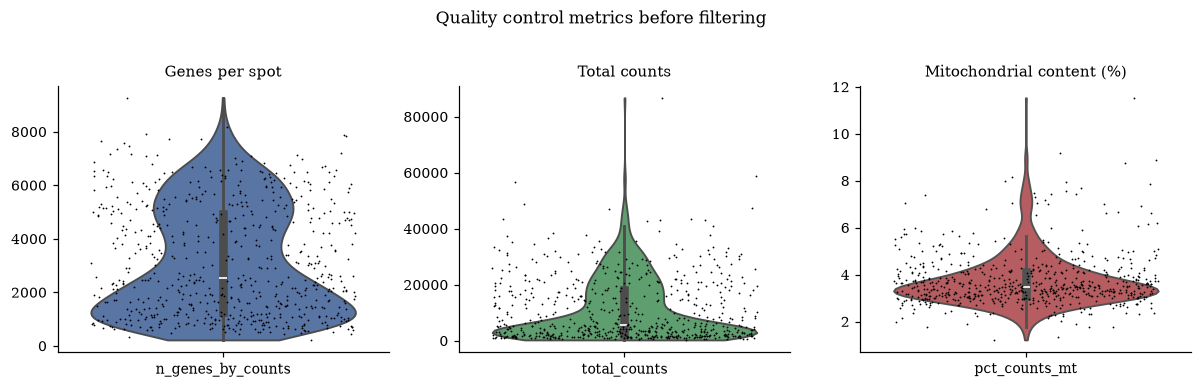

In [9]:
metrics = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
titles  = ["Genes per spot", "Total counts", "Mitochondrial content (%)"]
colors  = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    sc.pl.violin(data, keys=metric, ax=ax, show=False,
                 jitter=0.4, size=1.2, color=color, inner="box")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Quality control metrics before filtering", y=1.02)
plt.tight_layout()
save_fig(fig, "01_qc_before")
plt.show()

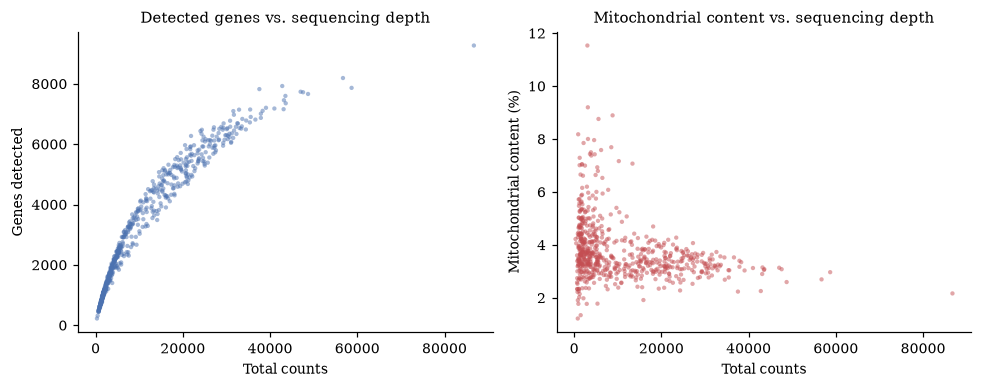

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].scatter(data.obs["total_counts"], data.obs["n_genes_by_counts"],
                s=8, alpha=0.5, color="#4C72B0", edgecolors="none")
axes[0].set_xlabel("Total counts")
axes[0].set_ylabel("Genes detected")
axes[0].set_title("Detected genes vs. sequencing depth")

axes[1].scatter(data.obs["total_counts"], data.obs["pct_counts_mt"],
                s=8, alpha=0.5, color="#C44E52", edgecolors="none")
axes[1].set_xlabel("Total counts")
axes[1].set_ylabel("Mitochondrial content (%)")
axes[1].set_title("Mitochondrial content vs. sequencing depth")

plt.tight_layout()
save_fig(fig, "02_qc_scatter")
plt.show()

### 1.1 Quality assessment and filtering

The purpose of this step is first to establish the condition of the section and only
then to remove spots. Fixed cutoffs transfer poorly between datasets, because they
ignore how deeply the particular section was sequenced. The criteria used here are
therefore derived from the distribution of the section itself: a spot is discarded if
a metric deviates by more than three median absolute deviations (MAD) from the median
of that metric. The MAD is used instead of the standard deviation because it is not
itself inflated by the outliers that are to be detected. A lower bound of 200 detected
genes is imposed in addition, so that the criterion cannot become permissive if the
section as a whole is shallow.

No upper bound is placed on the library size. In single-cell data an unusually high
count indicates that two cells entered the same droplet, but a spatial spot is a
mixture of cells by construction and this criterion has no equivalent here. A large
library size instead reflects local cell density, which is biology, or local capture
efficiency, which is precisely what library-size normalization corrects for. The
consequences of applying the bound nevertheless are quantified in the diagnostic
below.

! The section arrives already curated: the deposited file carries per-spot quality
metrics computed by the original submitters, so the worst spots were plausibly
removed before deposition. The assessment performed here is therefore an independent
verification rather than a first pass, and the criteria are expected to remove few
spots. That they do is itself a result: it establishes that the spatial patterns
described later cannot be attributed to a quality gradient across the slide.

In [11]:
def mad_bounds(values, n_mad=3):
    """Median +/- n_mad median absolute deviations (normal-consistent scaling)."""
    med = np.median(values)
    mad = median_abs_deviation(values, scale="normal")
    return med - n_mad * mad, med + n_mad * mad, med, mad


gene_lo, gene_hi, gene_med, gene_mad     = mad_bounds(data.obs["n_genes_by_counts"])
count_lo, count_hi, count_med, count_mad = mad_bounds(data.obs["total_counts"])
mt_lo, mt_hi, mt_med, mt_mad             = mad_bounds(data.obs["pct_counts_mt"])

min_gene_threshold  = max(200, gene_lo)   # absolute floor on transcriptional complexity
max_gene_threshold  = gene_hi
min_count_threshold = max(0, count_lo)
max_mt_threshold    = mt_hi

# The upper library-size bound that the MAD rule would suggest is retained as a
# variable for the diagnostic below, but is not used for filtering.
count_hi_unused     = count_hi
max_count_threshold = np.inf

thresholds = pd.DataFrame({
    "metric": ["Genes per spot", "Genes per spot",
               "Total counts", "Total counts",
               "Mitochondrial content (%)"],
    "bound":  ["min", "max", "min", "max", "max"],
    "median": [gene_med, gene_med, count_med, count_med, mt_med],
    "MAD":    [gene_mad, gene_mad, count_mad, count_mad, mt_mad],
    "median + 3 MAD": [gene_lo, gene_hi, count_lo, count_hi_unused, mt_hi],
    "applied": [min_gene_threshold, max_gene_threshold,
                min_count_threshold, np.nan, max_mt_threshold],
}).round(2)

thresholds

,metric,bound,median,MAD,median + 3 MAD,applied
0,Genes per spot,min,2535.00,2326.20,-4443.61,200.00
1,Genes per spot,max,2535.00,2326.20,9513.61,9513.61
2,Total counts,min,5756.00,6447.84,-13587.51,0.00
3,Total counts,max,5756.00,6447.84,25099.51,NaN
4,Mitochondrial content (%),max,3.49,0.71,5.61,5.61


In [12]:
# How many spots each criterion removes on its own.
criteria = {
    "too few genes":              data.obs["n_genes_by_counts"] <= min_gene_threshold,
    "too many genes":             data.obs["n_genes_by_counts"] >= max_gene_threshold,
    "too few counts":             data.obs["total_counts"]      <= min_count_threshold,
    "high mitochondrial content": data.obs["pct_counts_mt"]     >= max_mt_threshold,
}

for label, mask in criteria.items():
    print(f"Spots failing '{label}': {int(mask.sum())}")

Spots failing 'too few genes': 0
Spots failing 'too many genes': 0
Spots failing 'too few counts': 0
Spots failing 'high mitochondrial content': 41


In [13]:
keep = (
    (data.obs["n_genes_by_counts"] > min_gene_threshold) &
    (data.obs["n_genes_by_counts"] < max_gene_threshold) &
    (data.obs["total_counts"]      > min_count_threshold) &
    (data.obs["total_counts"]      < max_count_threshold) &   # np.inf, no effect
    (data.obs["pct_counts_mt"]     < max_mt_threshold)
)

adata = data[keep].copy()
print(f"Spots retained after quality control: {adata.n_obs} of {data.n_obs}")

Spots retained after quality control: 604 of 645


In [14]:
original = sc.read_h5ad(ST_PATH)
original.var_names_make_unique()


def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)


in_data  = original.obs_names.isin(data.obs_names)    # passed the min_counts filter
in_adata = original.obs_names.isin(adata.obs_names)   # passed the full QC
qc_removed = in_data & ~in_adata

mt_mask = original.var_names.str.upper().str.match(r"^MT[-\.]")
mt_pct = (np.asarray(to_dense(original[:, mt_mask].X)).sum(axis=1) /
          np.asarray(to_dense(original.X)).sum(axis=1) * 100)

group = pd.Series("retained (within count bound)", index=original.obs_names, dtype=object)
group[~in_data] = "removed: <100 UMI"
group[qc_removed] = "removed: high mitochondrial"
group[in_adata & (original.obs["total_counts"] >= count_hi_unused).values] = \
    "retained (would fail count bound)"

print(group.value_counts())

retained (within count bound)        523
retained (would fail count bound)     81
removed: high mitochondrial           41
removed: <100 UMI                      1
Name: count, dtype: int64


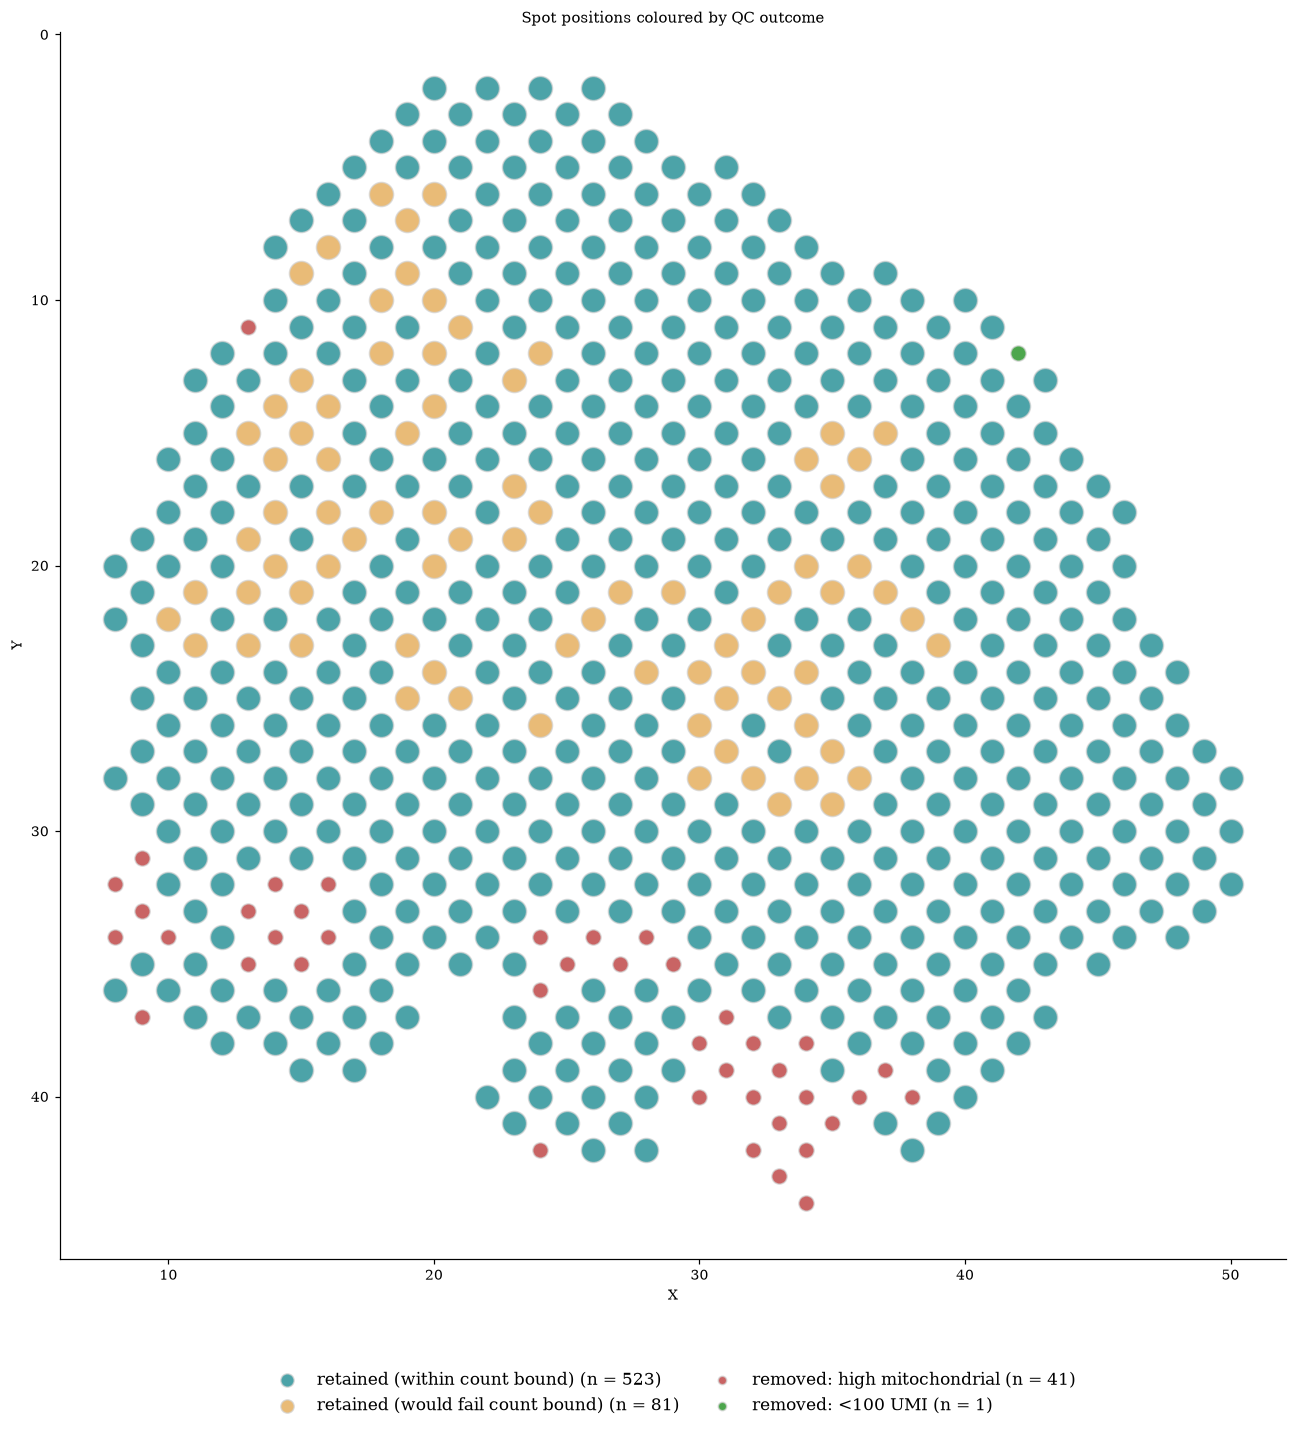

In [70]:
xy = original.obsm["spatial"]

group_style = {
    "retained (within count bound)":      ("#007C83", 250), 
    "retained (would fail count bound)":  ("#E09F3E", 250),  
    "removed: high mitochondrial":        ("firebrick", 100),  
    "removed: <100 UMI":                  ("green", 100),  
}

fig, ax = plt.subplots(figsize=(13,13))

for label, (color, size) in group_style.items():
    m = (group == label).values
    if m.sum() == 0:
        continue

    ax.scatter(
        xy[m, 0], xy[m, 1],
        s=size,
        c=color,
        marker="o",
        alpha=0.7,
        edgecolors="lightgray",
        label=f"{label} (n = {m.sum()})"
    )

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Spot positions coloured by QC outcome")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
    fontsize=11,
    markerscale=0.55,
    ncol=2,
    columnspacing=1.5,
    handletextpad=0.8
)

plt.tight_layout()
save_fig(fig, "03_qc_spatial_outcome")
plt.show()

In [16]:
panel = {
    "keratinocyte": ["KRT5", "KRT14", "KRT6A", "KRT17"],
    "stromal":      ["COL1A1", "COL1A2", "DCN", "LUM"],
    "immune":       ["PTPRC", "CD74", "HLA.DRA", "CD14"],
}

norm = original.copy()
sc.pp.normalize_total(norm, target_sum=1e4)
sc.pp.log1p(norm)

scores = {}
for name, genes in panel.items():
    present = [g for g in genes if g in norm.var_names]
    scores[name] = np.asarray(to_dense(norm[:, present].X)).mean(axis=1)
scores["total counts"] = np.asarray(to_dense(original.X)).sum(axis=1)

profile = pd.DataFrame(scores, index=original.obs_names)
profile["group"] = group.values
profile.groupby("group").mean().round(2)

,keratinocyte,stromal,immune,total counts
group,,,,
removed: <100 UMI,5.96,2.36,0.00,90.000000
removed: high mitochondrial,4.10,2.79,1.48,4078.800049
retained (within count bound),4.53,2.86,1.27,8158.549805
retained (would fail count bound),4.47,2.10,0.98,33363.660156


The spots that the upper count bound would discard are not randomly placed: they form
diagonal bands in the upper left and centre of the section. Their marker profile,
however, is that of an average retained spot — the keratinocyte score is 4.47 against
4.53 for the retained spots, with slightly lower stromal and immune scores — while
their library size is roughly four times larger. They are therefore not a distinct
compartment sequenced separately, but ordinary tissue read more deeply. Whether this
reflects higher local cell density or higher capture efficiency, discarding the spots
is not the appropriate response: the first is biology and the second is removed by
normalization. The bound was accordingly not applied, retaining 81 spots that a
default single-cell pipeline would have lost.

The spots failing the mitochondrial criterion behave differently. They carry about
half the counts of a retained spot, show a reduced keratinocyte score, and cluster
along the lower edge of the section, which is the pattern expected where RNA
integrity is compromised. These spots were removed. Because the lower part of the
section is also where the stromal and inflammatory compartments lie, this filter may
remove spots selectively from those regions; the point is taken up in the discussion.

The single spot below 100 UMI was removed before the MAD estimates were computed, so
that it could not influence the thresholds derived from them.

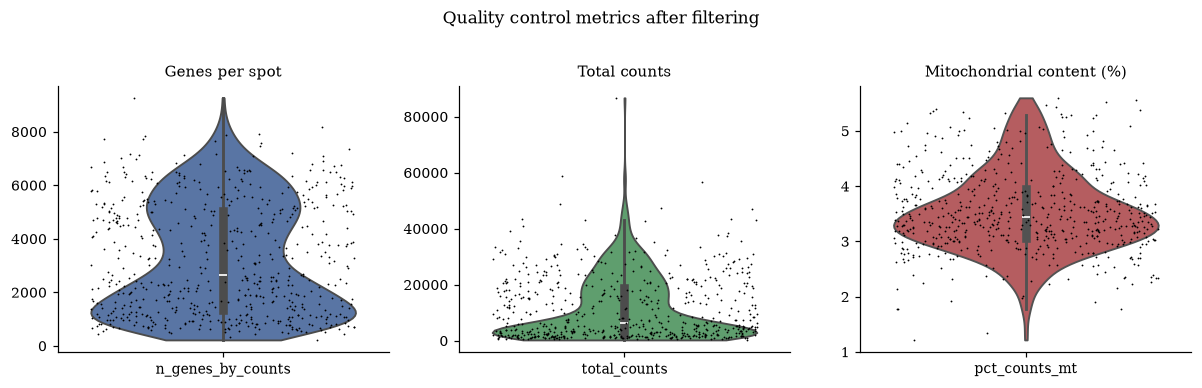

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    sc.pl.violin(adata, keys=metric, ax=ax, show=False,
                 jitter=0.4, size=1.2, color=color, inner="box")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Quality control metrics after filtering", y=1.02)
plt.tight_layout()
save_fig(fig, "04_qc_after")
plt.show()

In [18]:
# Genes no longer detected anywhere after spot filtering carry no information.
n_genes_before = adata.n_vars
sc.pp.filter_genes(adata, min_cells=3)

print(f"Genes: {n_genes_before} -> {adata.n_vars} "
      f"({n_genes_before - adata.n_vars} removed)")

Genes: 16962 -> 14889 (2073 removed)


### 1.2 Normalization

Spots differ in sequencing depth and capture efficiency, so an unnormalized profile
with more total reads appears to express every gene more strongly. Each spot is
therefore rescaled to a common library size of 10,000 counts.

Three representations are kept side by side as layers, because the later steps need
different ones:

| layer | content | used for |
|---|---|---|
| `raw_counts` | counts as sequenced | library-size diagnostics |
| `norm_counts` | rescaled to 10,000 counts per spot, **linear scale** | deconvolution input (Week 2) |
| `log_counts` | `log1p` of the normalized counts | visualization, gene ranking, differential expression (Week 3) |

The distinction matters for the deconvolution. The mixture model is additive, so the
matrices entering it must stay on a linear scale; `norm_counts`, not `log_counts`, is
the layer passed to Deconomix. The logarithmic version is used only where variance
stabilization is desirable and additivity is irrelevant.

In [19]:
adata.layers["raw_counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
adata.layers["norm_counts"] = adata.X.copy()

sc.pp.log1p(adata)
adata.layers["log_counts"] = adata.X.copy()

print("Layers:", list(adata.layers.keys()))

Layers: [None, 'raw_counts', 'norm_counts', 'log_counts']


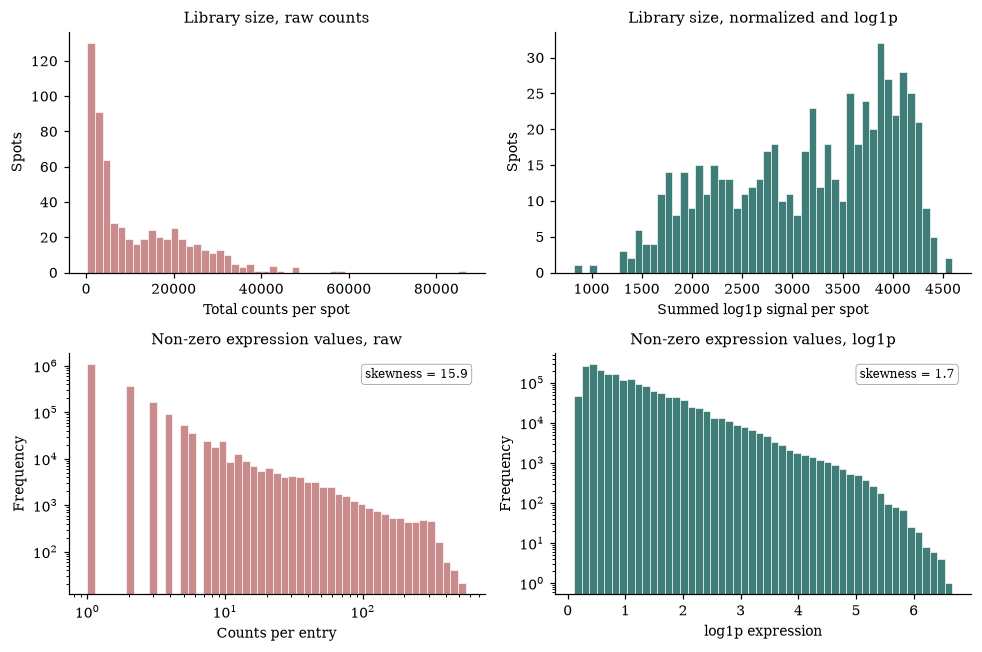

In [20]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)


counts_raw = to_dense(adata.layers["raw_counts"])
counts_log = to_dense(adata.layers["log_counts"])

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
box = dict(boxstyle="round,pad=0.3", fc="white", ec="0.6", lw=0.5)

axes[0, 0].hist(counts_raw.sum(axis=1), bins=50,
                color="#c98b8b", edgecolor="white", linewidth=0.4)
axes[0, 0].set_title("Library size, raw counts")
axes[0, 0].set_xlabel("Total counts per spot")
axes[0, 0].set_ylabel("Spots")

axes[0, 1].hist(counts_log.sum(axis=1), bins=50,
                color="#3f7d78", edgecolor="white", linewidth=0.4)
axes[0, 1].set_title("Library size, normalized and log1p")
axes[0, 1].set_xlabel("Summed log1p signal per spot")
axes[0, 1].set_ylabel("Spots")

values_raw = counts_raw[counts_raw > 0]
axes[1, 0].hist(values_raw,
                bins=np.logspace(0, np.log10(values_raw.max()), 50),
                color="#c98b8b", edgecolor="white", linewidth=0.4)
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Non-zero expression values, raw")
axes[1, 0].set_xlabel("Counts per entry")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].text(0.96, 0.94, f"skewness = {pd.Series(values_raw).skew():.1f}",
                transform=axes[1, 0].transAxes, ha="right", va="top",
                fontsize=8, bbox=box)

values_log = counts_log[counts_log > 0]
axes[1, 1].hist(values_log, bins=50,
                color="#3f7d78", edgecolor="white", linewidth=0.4)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Non-zero expression values, log1p")
axes[1, 1].set_xlabel("log1p expression")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].text(0.96, 0.94, f"skewness = {pd.Series(values_log).skew():.1f}",
                transform=axes[1, 1].transAxes, ha="right", va="top",
                fontsize=8, bbox=box)

plt.tight_layout()
save_fig(fig, "05_normalization_effect")
plt.show()

In [21]:
coordinates = adata.obsm["spatial"]

print(adata)
print()
print(f"Spots retained: {adata.n_obs}")
print(f"Genes retained: {adata.n_vars}")

AnnData object with n_obs × n_vars = 604 × 14889
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p'
    obsm: 'spatial'
    layers: None (.X), 'raw_counts', 'norm_counts', 'log_counts'

Spots retained: 604
Genes retained: 14889


### 1.3 Gene rankings

Two rankings summarize the expression matrix from complementary angles. Ranking by
mean expression identifies the transcriptional programmes that dominate the section
as a whole. Ranking by variance across spots identifies genes whose expression
differs between regions, which is the property relevant for spatial structure: a gene
can be highly expressed everywhere and thus carry no positional information, or be
moderately expressed but confined to one compartment and be highly informative.

Both rankings are computed on the log-normalized layer, and each is reported once
with and once without mitochondrial genes. Mitochondrial transcripts are abundant and
would otherwise occupy positions in the mean ranking that reflect metabolic activity
and tissue handling rather than cell identity.

In [22]:
def rank_genes(ad, layer="log_counts", exclude_mt=False):
    """Rank genes by mean expression and by variance across spots."""
    subset = ad[:, ~ad.var["mt"]] if exclude_mt else ad
    matrix = np.asarray(to_dense(subset.layers[layer]), dtype=np.float64)

    mean_rank = pd.Series(matrix.mean(axis=0), index=subset.var_names,
                          name="mean_expression")
    var_rank = pd.Series(matrix.var(axis=0), index=subset.var_names,
                         name="variance")
    return (mean_rank.sort_values(ascending=False),
            var_rank.sort_values(ascending=False))


mean_all, var_all = rank_genes(adata, exclude_mt=False)
mean_bio, var_bio = rank_genes(adata, exclude_mt=True)

pd.DataFrame({
    "mean (all)":     mean_all.head(10).index,
    "mean (no MT)":   mean_bio.head(10).index,
    "variance (all)": var_all.head(10).index,
    "variance (no MT)": var_bio.head(10).index,
})

,mean (all),mean (no MT),variance (all),variance (no MT)
0,KRT6A,KRT6A,KRT2,KRT2
1,KRT6B,KRT6B,IGFBP4,IGFBP4
2,KRT14,KRT14,DCD,DCD
3,S100A8,S100A8,HLA.DRA,HLA.DRA
4,KRT16,KRT16,CALML5,CALML5
5,KRT6C,KRT6C,DCN,DCN
6,KRT5,KRT5,KRT1,KRT1
7,MT.CO2,S100A9,RNASE1,RNASE1
8,S100A9,KRT17,CD74,CD74
9,MT.CO3,COL1A1,SPINK5,SPINK5


In [23]:
for name, series in [("mean_ranking_all", mean_all),
                     ("mean_ranking_no_mt", mean_bio),
                     ("var_ranking_all", var_all),
                     ("var_ranking_no_mt", var_bio)]:
    path = RANK_DIR / f"{name}.csv"
    series.to_csv(path, header=True, index_label="gene")
    print(f"Saved {path} ({len(series)} genes)")

Saved rankings\mean_ranking_all.csv (14889 genes)
Saved rankings\mean_ranking_no_mt.csv (14876 genes)
Saved rankings\var_ranking_all.csv (14889 genes)
Saved rankings\var_ranking_no_mt.csv (14876 genes)


In [24]:
# A gene can reach a high variance either by being expressed everywhere at
# different levels, or by being absent from part of the section. The fraction of
# spots without any signal separates the two cases.
summary = []
for gene in list(mean_bio.head(5).index) + list(var_bio.head(5).index):
    expr = np.asarray(to_dense(adata[:, gene].layers["log_counts"])).ravel()
    summary.append({
        "gene":        gene,
        "ranked by":   "mean" if gene in mean_bio.head(5).index else "variance",
        "min":         expr.min(),
        "max":         expr.max(),
        "zero spots %": 100 * (expr == 0).mean(),
    })

pd.DataFrame(summary).round(2)

,gene,ranked by,min,max,zero spots %
0,KRT6A,mean,2.24,6.17,0.00
1,KRT6B,mean,2.67,6.15,0.00
2,KRT14,mean,3.17,6.05,0.00
3,S100A8,mean,2.88,5.87,0.00
4,KRT16,mean,2.70,5.48,0.00
5,KRT2,variance,0.00,6.13,11.59
6,IGFBP4,variance,0.00,4.47,9.60
7,DCD,variance,0.00,6.67,1.82
8,HLA.DRA,variance,0.00,3.99,19.54
9,CALML5,variance,0.00,4.96,11.75


### 1.4 Spatial visualization

In [25]:
def spatial_scatter(values, ax=None, title=None, cmap="viridis",
                    size=45, colorbar=True, label=None):
    """Colour the spots of the section by a per-spot quantity."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    sca = ax.scatter(coordinates[:, 0], coordinates[:, 1],
                     c=np.asarray(values), cmap=cmap, s=size,
                     marker="o", edgecolors="none")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title)
    if colorbar:
        cbar = ax.figure.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)
        if label:
            cbar.set_label(label, fontsize=8)
        cbar.ax.tick_params(labelsize=7)
    return sca


def gene_expression(gene, layer="log_counts"):
    """Expression of one gene across all spots, as a flat array."""
    return np.asarray(to_dense(adata[:, gene].layers[layer])).ravel()

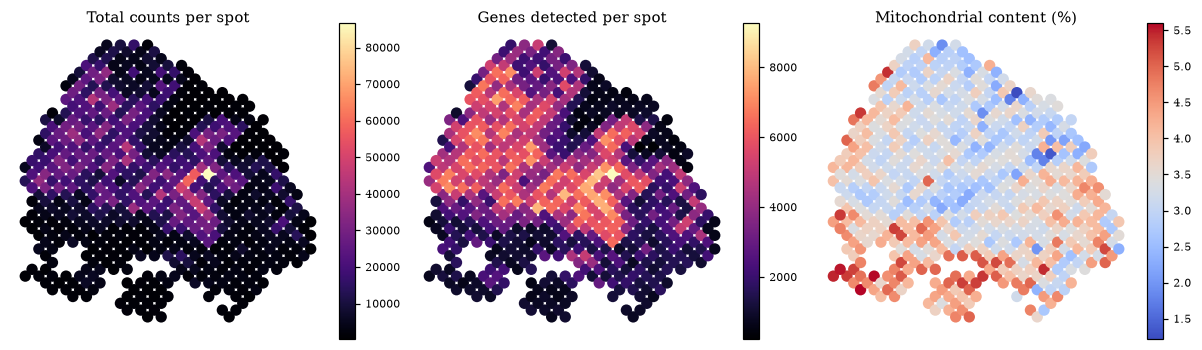

In [26]:
# How much material each spot contains, and how clean it is. 
depth = np.asarray(to_dense(adata.layers["raw_counts"])).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))

spatial_scatter(depth, ax=axes[0],
                title="Total counts per spot", cmap="magma", size=55)
spatial_scatter(adata.obs["n_genes_by_counts"], ax=axes[1],
                title="Genes detected per spot", cmap="magma", size=55)
spatial_scatter(adata.obs["pct_counts_mt"], ax=axes[2],
                title="Mitochondrial content (%)", cmap="coolwarm", size=55)

plt.tight_layout()
save_fig(fig, "06_spatial_distribution")
plt.show()

The first two maps show the same pattern: spots with more counts also detect more
genes, which is the normal relationship. The signal is stronger in the upper and
central part of the section and weaker along the lower edge. As the gene maps below
show, the lower edge is the stromal part of the tissue. Epidermis and tumour nests are
densely packed with cells, while stroma is much looser, so fewer cells and less RNA
fall under each spot there. The difference is therefore mainly a property of the
tissue and not a defect of the measurement.

Mitochondrial content stays within a narrow range across the whole section and is
slightly higher along the same lower edge. No region of the section is empty or
strongly degraded, so the maps that follow can be read as biology.

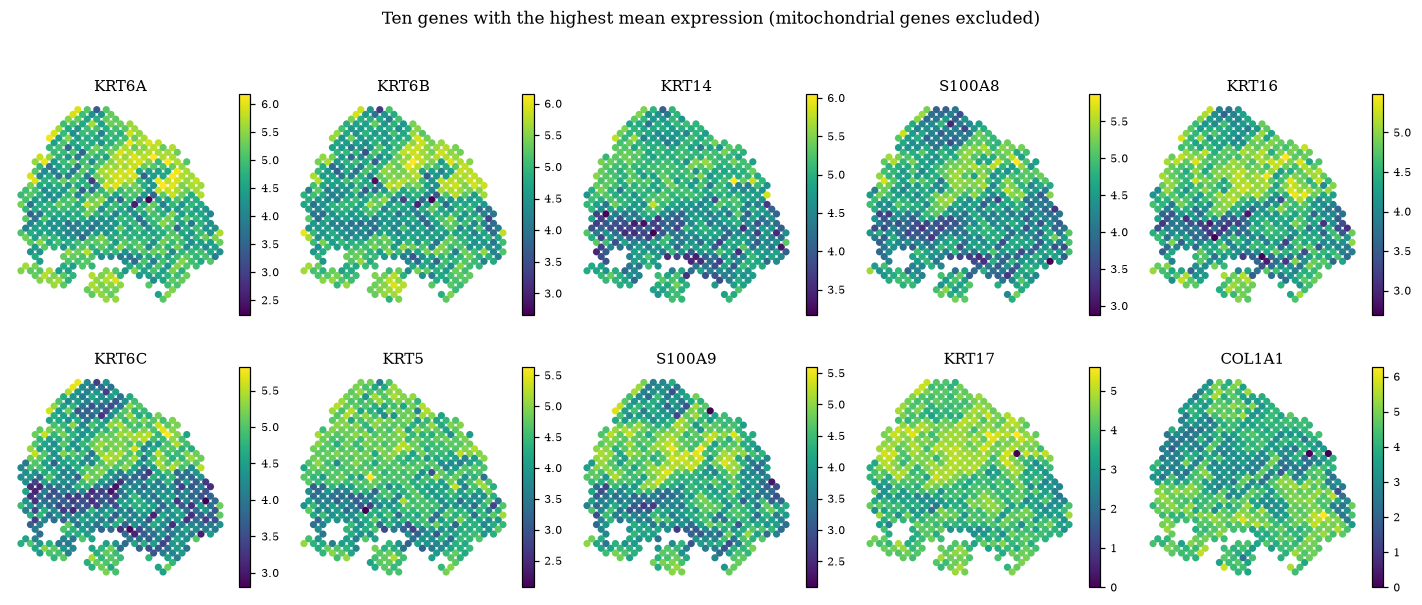

In [27]:
genes = list(mean_bio.head(10).index)

fig, axes = plt.subplots(2, 5, figsize=(13, 5.6))
for ax, gene in zip(axes.ravel(), genes):
    spatial_scatter(gene_expression(gene), ax=ax, title=gene, size=22)

fig.suptitle("Ten genes with the highest mean expression (mitochondrial genes excluded)",
             y=1.01)
plt.tight_layout()
save_fig(fig, "07_spatial_top_mean")
plt.show()

Nine of the ten genes with the highest mean expression are keratinocyte genes. KRT5
and KRT14 are markers of the basal layer of the epidermis. KRT6A, KRT6B, KRT6C, KRT16
and KRT17 are the keratins of activated keratinocytes: they are switched on when
keratinocytes proliferate, in wound healing and in tumours, and are only weakly
expressed in resting skin. S100A8 and S100A9 are inflammation-associated genes.
COL1A1, a collagen produced by fibroblasts, is the only stromal gene in the list.

This fits the sample. The section comes from a cutaneous squamous cell carcinoma,
a tumour that arises from keratinocytes, so keratinocytes make up most of the tissue,
in the tumour as well as in the surrounding skin.

These genes are detected in nearly every spot. Their level changes across the section,
and COL1A1 is clearly restricted to the lower part, but most of them do not mark a
boundary between regions. A high mean expression tells us which programmes dominate
the section as a whole; it says little about where one region ends and the next
begins.

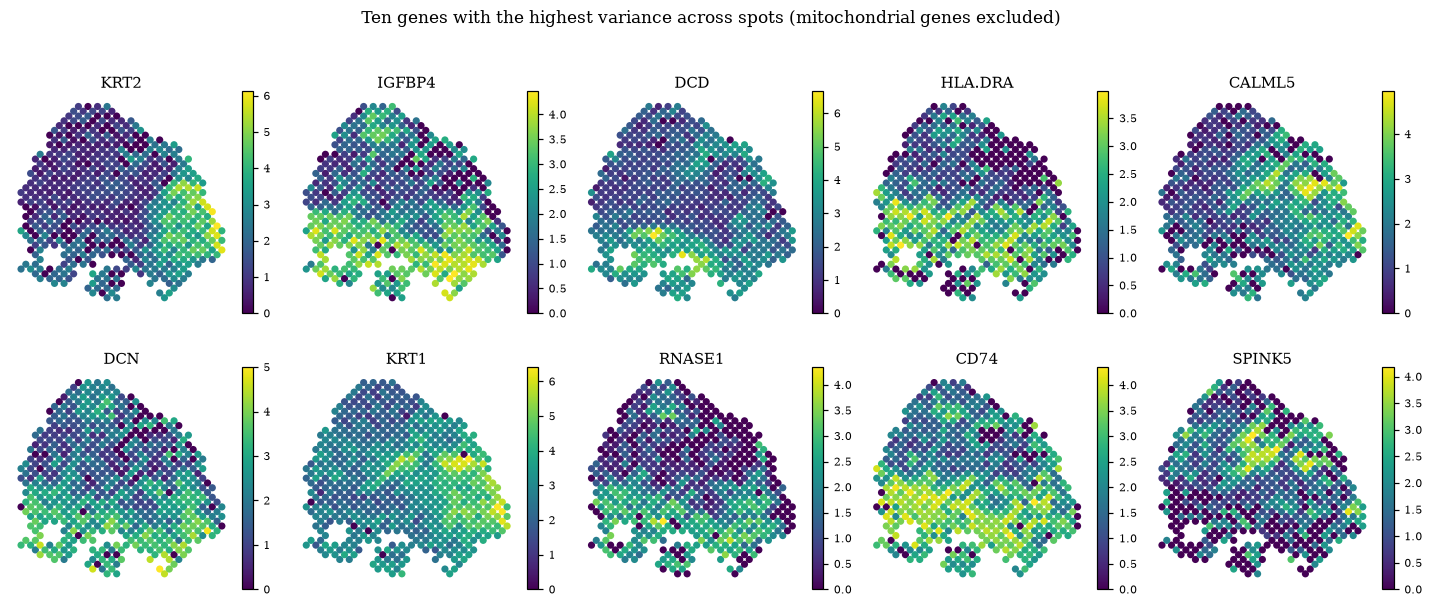

In [28]:
genes = list(var_bio.head(10).index)

fig, axes = plt.subplots(2, 5, figsize=(13, 5.6))
for ax, gene in zip(axes.ravel(), genes):
    spatial_scatter(gene_expression(gene), ax=ax, title=gene, size=22)

fig.suptitle("Ten genes with the highest variance across spots (mitochondrial genes excluded)",
             y=1.01)
plt.tight_layout()
save_fig(fig, "08_spatial_top_variance")
plt.show()

The variance ranking behaves very differently. These genes are present in one part of
the section and absent from the rest, and together they divide the tissue into three
areas.

KRT1, KRT2, CALML5 and SPINK5 are strongest on the right-hand side. All four belong to
differentiated keratinocytes in the upper layers of the epidermis, so this area is
normal, mature skin rather than tumour. DCD is expressed only by eccrine sweat glands
and marks a small region on the same side, which is another structure of normal skin.

IGFBP4 and DCN mark the lower part of the section. Both are fibroblast and
extracellular matrix genes, so this is the stromal compartment.

CD74, HLA-DRA and RNASE1 mark a partly overlapping area in the lower and central
region. CD74 and HLA-DRA belong to the MHC class II complex and are expressed by
antigen-presenting cells such as macrophages and dendritic cells; RNASE1 is expressed
by macrophages and endothelial cells. Immune cells are therefore found mainly inside
the stromal compartment, not spread evenly over the tissue.

Comparing the two rankings gives a first picture of the section: activated
keratinocytes across the upper and left part, differentiated normal epidermis with a
sweat gland on the right, and a stroma containing fibroblasts, vessels and immune
cells along the bottom. Ji et al. reported the same kind of arrangement for these
tumours, with tumour keratinocytes bordered by a stroma rich in fibroblasts and
endothelial cells.

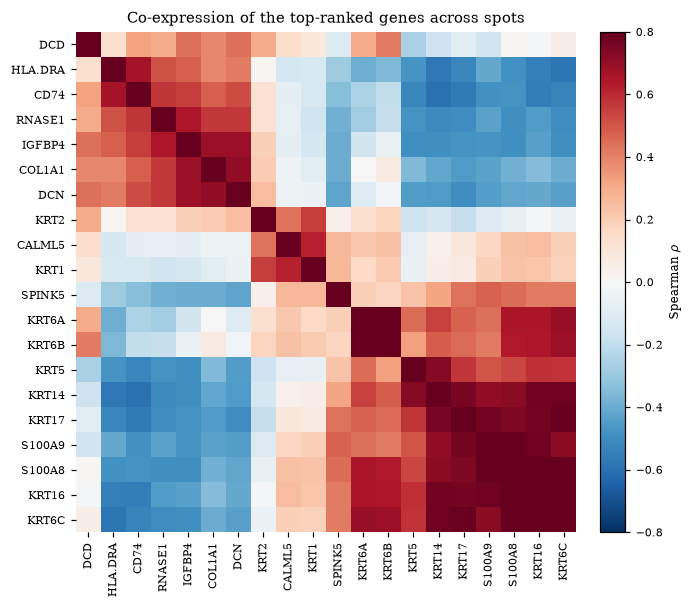

In [29]:
# The two rankings are combined here for the one question they share: do the
# top-ranked genes fall into groups that are expressed together? Genes are ordered by
# hierarchical clustering of the correlation matrix, so that groups appear as blocks
# along the diagonal.
ranked_genes = list(dict.fromkeys(list(mean_bio.head(10).index) +
                                  list(var_bio.head(10).index)))

expr_top = pd.DataFrame(
    np.asarray(to_dense(adata[:, ranked_genes].layers["log_counts"])),
    columns=ranked_genes,
)
corr = expr_top.corr(method="spearman")

order = leaves_list(linkage(squareform(1 - corr.values, checks=False), method="average"))
corr = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(6.5, 5.6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-0.8, vmax=0.8)

ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=7.5)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman $\\rho$", fontsize=8)
cbar.ax.tick_params(labelsize=7)

ax.set_title("Co-expression of the top-ranked genes across spots")
plt.tight_layout()
save_fig(fig, "09_coexpression_heatmap")
plt.show()

The correlation matrix contains three blocks.

The first holds COL1A1, DCN, IGFBP4 and RNASE1 together with CD74 and HLA-DRA: the
stromal and immune genes. The second holds KRT1, KRT2 and CALML5, the differentiation
genes, with SPINK5 at its edge. The third holds KRT5, KRT14, KRT17, the KRT6 family,
KRT16, S100A8 and S100A9, the basal and activated keratinocyte genes. DCD belongs to
none of the blocks, which suits a gene expressed only by sweat glands.

The first and third blocks are strongly negatively correlated. A spot contains either
keratinocytes or stroma with immune cells, rarely both in equal amounts. This is the
tumour–stroma axis of the section.

The two keratinocyte blocks are only weakly related to each other, and not negatively.
They describe the same cell type in two different states, basal and activated on one
side, differentiated on the other.

In [30]:
# Snapshot of the curated section, so that Weeks 2 and 3 can be run without repeating
# the preprocessing above.
adata.write_h5ad(PROC_DIR / "st_curated.h5ad")
print(f"Written: {PROC_DIR / 'st_curated.h5ad'}")
print(adata)

Written: Data\processed\st_curated.h5ad
AnnData object with n_obs × n_vars = 604 × 14889
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p'
    obsm: 'spatial'
    layers: None (.X), 'raw_counts', 'norm_counts', 'log_counts'


## 2. Week 2 — Cell-type deconvolution

Each spot in the section contains several cells, so its expression profile is a
mixture. This part estimates how much each cell type contributes to each spot.

The method used is Digital Tissue Deconvolution as implemented in the `deconomix`
package. It needs two things: a reference profile for every cell type that may occur
in the tissue, and a set of training mixtures of known composition from which gene
weights can be learned. Both are built from the single-cell data of the same study
that produced the section.

In [31]:
PATIENTS = ["P2", "P5", "P10"]

meta = pd.read_csv(SC_DIR / "patient_metadata_new.txt", sep="\t", index_col=0)
meta.index = meta.index.str.strip('"')

ref_meta = meta[meta["patient"].isin(PATIENTS)].copy()

print("Cells in the full metadata:", meta.shape[0])
print("Cells from the selected patients:", ref_meta.shape[0])
print(ref_meta["patient"].value_counts())
ref_meta.head()

Cells in the full metadata: 48164
Cells from the selected patients: 13887
patient
P2     6824
P10    4569
P5     2494
Name: count, dtype: int64


,nCount_RNA,nFeature_RNA,patient,tum.norm,level1_celltype,level2_celltype,level3_celltype
P2_Tumor_AAACCTGAGATCCGAG,11132,2468,P2,Tumor,CLEC9A,CLEC9A,CLEC9A
P2_Tumor_AAACCTGAGCGATAGC,5296,2086,P2,Tumor,Endothelial Cell,Endothelial Cell,Endothelial Cell
P2_Tumor_AAACCTGAGGATGCGT,11557,2771,P2,Tumor,CD1C,CD1C,CD1C
P2_Tumor_AAACCTGCATTCTCAT,12307,3203,P2,Tumor,Epithelial,Keratinocyte,Keratinocyte
P2_Tumor_AAACCTGGTCCATCCT,26225,4705,P2,Tumor,Epithelial,Tumor_KC_Cyc,Tumor_KC_Cyc


In [32]:
# The count matrix contains all ten patients of the study and is too large to load in
# full. It is filtered column by column while streaming through the file, and the
# result is cached, so this runs only once.
def strip_quotes(text):
    return text.strip().strip('"')


input_file = SC_DIR / "merge10pts_counts.txt"
filtered_file = PROC_DIR / "P2_P5_P10_counts.txt"
prefixes = tuple(f"{p}_" for p in PATIENTS)

if filtered_file.exists():
    print(f"{filtered_file} already exists, skipping the filter.")
else:
    with open(input_file) as fin, open(filtered_file, "w") as fout:
        header = fin.readline().rstrip("\n").split("\t")
        clean_header = [strip_quotes(h) for h in header]

        keep_idx = [i for i, name in enumerate(clean_header)
                    if name.startswith(prefixes)]
        print("Columns kept:", len(keep_idx))
        print("Per patient:", dict(Counter(
            name.split("_")[0] for i, name in enumerate(clean_header) if i in set(keep_idx))))

        fout.write("\t".join(header[i] for i in keep_idx) + "\n")

        # Two rows of the file hold sample annotation rather than gene counts.
        n_genes, n_skipped = 0, 0
        for line in fin:
            fields = line.rstrip("\n").split("\t")
            if strip_quotes(fields[0]) in ("Patient", "Tissue: 0=Normal, 1=Tumor"):
                n_skipped += 1
                continue
            fout.write("\t".join([fields[0]] + [fields[i + 1] for i in keep_idx]) + "\n")
            n_genes += 1

        print(f"Annotation rows skipped: {n_skipped}, gene rows written: {n_genes}")

Data\processed\P2_P5_P10_counts.txt already exists, skipping the filter.


In [33]:
counts_pickle = PROC_DIR / "P2_P5_P10_counts_raw.pkl"

if counts_pickle.exists():
    ref_counts = pd.read_pickle(counts_pickle)
    print("Loaded the cached count matrix.")
else:
    ref_counts = pd.read_csv(filtered_file, sep="\t", index_col=0)
    ref_counts.columns = [c.strip('"') for c in ref_counts.columns]
    ref_counts.index = [i.strip('"') for i in ref_counts.index]
    ref_counts.to_pickle(counts_pickle)
    print("Parsed the text file and cached it.")

# The barcodes of the counts and of the metadata must describe the same cells, and the
# values must still be raw integers.
sample_values = ref_counts.iloc[:200, :50].values.flatten()

print(f"\nref_counts: {ref_counts.shape} (gene x cell)")
print("Barcodes match the metadata:", set(ref_meta.index) == set(ref_counts.columns))
print("Values are raw integer counts:",
      bool((sample_values == sample_values.astype(int)).all()))

Loaded the cached count matrix.

ref_counts: (32738, 13887) (gene x cell)
Barcodes match the metadata: True
Values are raw integer counts: True


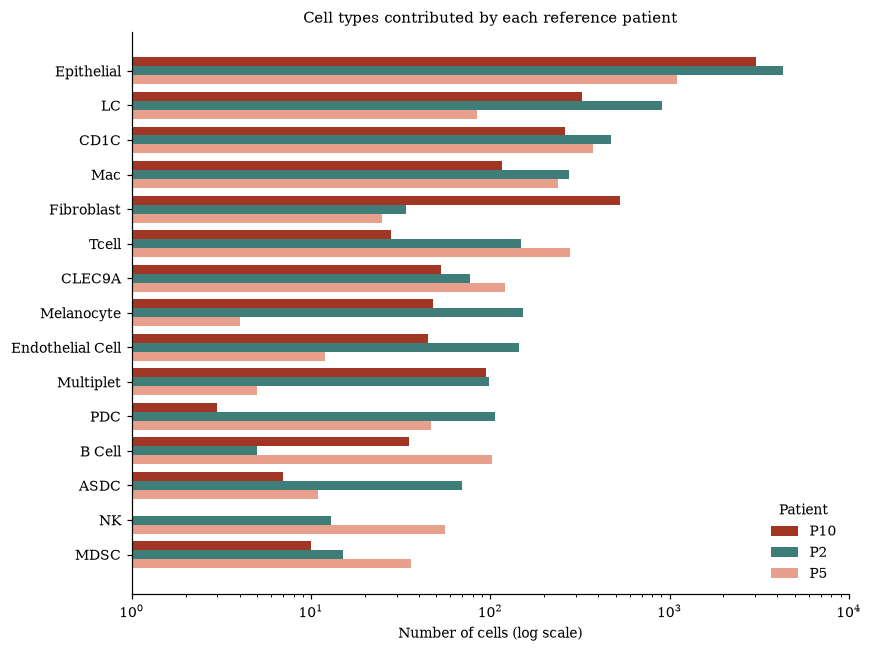

In [34]:
# Which cell types each patient contributes. A log scale is used because the counts
# span three orders of magnitude.
table = pd.crosstab(ref_meta["patient"], ref_meta["level1_celltype"])
table = table[table.sum(axis=0).sort_values(ascending=False).index]

patient_colors = {"P2": "#3f7d78", "P5": "#e8a08d", "P10": "#a03623"}
y = np.arange(table.shape[1])
bar_height = 0.26

fig, ax = plt.subplots(figsize=(8, 6))
for i, patient in enumerate(table.index):
    offset = (i - (len(table.index) - 1) / 2) * bar_height
    ax.barh(y + offset, table.loc[patient].values, height=bar_height,
            color=patient_colors[patient], label=patient)

ax.set_xscale("log")
ax.set_xlim(1, 10000)
ax.set_yticks(y)
ax.set_yticklabels(table.columns)
ax.invert_yaxis()
ax.set_xlabel("Number of cells (log scale)")
ax.set_title("Cell types contributed by each reference patient")
ax.legend(title="Patient", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
#ax.grid(axis="x", linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, "10_reference_composition")
plt.show()

In [35]:
for level in ["level1_celltype", "level2_celltype", "level3_celltype"]:
    print(f"{level}: {ref_meta[level].nunique()} distinct labels")

print()
print(ref_meta["level1_celltype"].value_counts())

level1_celltype: 15 distinct labels
level2_celltype: 24 distinct labels
level3_celltype: 35 distinct labels

level1_celltype
Epithelial          8423
LC                  1314
CD1C                1105
Mac                  630
Fibroblast           585
Tcell                457
CLEC9A               251
Melanocyte           205
Endothelial Cell     202
Multiplet            199
PDC                  156
B Cell               142
ASDC                  88
NK                    69
MDSC                  61
Name: count, dtype: int64


### 2.2 Choosing the annotation level and filtering cell types

The data come with three levels of annotation. Level 3 has 34 labels and level 2 has
23, both of which split keratinocytes into tumour and normal states and T cells into
subtypes. Level 1 has 14 broad labels and is used here.

Two reasons. The task asks for roughly 10 to 15 types, and more importantly the
deconvolution has to separate the types from one another. Cell types with similar
expression profiles cannot be told apart by a linear model, and the finer levels
contain exactly such pairs. Level 1 also keeps enough cells per type for the averages
to be stable.

The price is that all keratinocytes fall into one class called `Epithelial`. The model
will therefore not distinguish tumour keratinocytes from normal ones, and in
particular cannot identify the tumour-specific keratinocytes described by Ji et al.
This limits what the results can say and is returned to in the discussion.

Two filters are applied. Cells labelled `Multiplet` are droplets that captured more
than one cell; their profiles are mixtures and would blur the reference, so they are
removed. Cell types with very few cells are then dropped, because an average built
from a handful of cells is dominated by those individual cells rather than by the type.

The cutoff used is 100 cells rather than the 500 suggested in the task. With a cutoff
of 500 only five types would survive, and T cells, endothelial cells, B cells and
melanocytes would all be lost, even though these are present in the tissue and are
part of the question. 

In [36]:
CELLTYPE_COL = "level1_celltype"
MIN_CELLS = 100

# Keep only cells present in both objects, then drop multiplets.
common_cells = ref_counts.columns.intersection(ref_meta.index)
ref_counts = ref_counts[common_cells]
ref_meta = ref_meta.loc[common_cells]

n_before = ref_meta.shape[0]
keep_cells = ref_meta[CELLTYPE_COL].notna() & (ref_meta[CELLTYPE_COL] != "Multiplet")
ref_meta = ref_meta[keep_cells].copy()
ref_counts = ref_counts[ref_meta.index]
print(f"Multiplets and unannotated cells removed: {n_before - ref_meta.shape[0]}")

# Drop cell types represented by too few cells.
counts_per_type = ref_meta[CELLTYPE_COL].value_counts()
keep_types = counts_per_type[counts_per_type >= MIN_CELLS].index.tolist()
dropped = counts_per_type[counts_per_type < MIN_CELLS]

print(f"\nCell types dropped (fewer than {MIN_CELLS} cells):")
print(dropped)
print(f"They account for {100 * dropped.sum() / ref_meta.shape[0]:.1f} % of the cells.")

ref_meta = ref_meta[ref_meta[CELLTYPE_COL].isin(keep_types)].copy()
ref_counts = ref_counts[ref_meta.index]

print(f"\nCells remaining: {ref_meta.shape[0]}")
print(f"Cell types remaining: {ref_meta[CELLTYPE_COL].nunique()}")


Multiplets and unannotated cells removed: 199

Cell types dropped (fewer than 100 cells):
level1_celltype
ASDC    88
NK      69
MDSC    61
Name: count, dtype: int64
They account for 1.6 % of the cells.

Cells remaining: 13470
Cell types remaining: 11


In [37]:
# Cap the number of cells per type, so that one abundant type does not dominate the
# artificial mixtures generated during training.
N_PER_TYPE = 5000
rng = np.random.default_rng(RANDOM_STATE)

selected_positions = []
type_array = ref_meta[CELLTYPE_COL].to_numpy()

for cell_type in sorted(np.unique(type_array)):
    indices = np.where(type_array == cell_type)[0]
    n_sample = min(N_PER_TYPE, len(indices))
    selected_positions.extend(rng.choice(indices, size=n_sample, replace=False))
    print(f"{cell_type:18s} {len(indices):5d} available -> {n_sample:5d} sampled")

selected_positions = np.sort(np.asarray(selected_positions, dtype=int))
ref_meta = ref_meta.iloc[selected_positions].copy()
ref_counts = ref_counts[ref_meta.index]

print(f"\nCells in the final reference: {ref_meta.shape[0]}")
print(ref_meta["patient"].value_counts())

B Cell               142 available ->   142 sampled
CD1C                1105 available ->  1105 sampled
CLEC9A               251 available ->   251 sampled
Endothelial Cell     202 available ->   202 sampled
Epithelial          8423 available ->  5000 sampled
Fibroblast           585 available ->   585 sampled
LC                  1314 available ->  1314 sampled
Mac                  630 available ->   630 sampled
Melanocyte           205 available ->   205 sampled
PDC                  156 available ->   156 sampled
Tcell                457 available ->   457 sampled

Cells in the final reference: 10047
patient
P2     4931
P10    3210
P5     1906
Name: count, dtype: int64


In [38]:
# Each cell is scaled to a total of 10,000 counts, the same target used for the
# spots. No log transformation is applied: the mixture model is additive and must be
# fitted on a linear scale.
cell_totals = ref_counts.sum(axis=0)

if (cell_totals == 0).any():
    keep = cell_totals[cell_totals > 0].index
    print(f"Dropping {(cell_totals == 0).sum()} cells with zero counts")
    ref_counts, ref_meta, cell_totals = ref_counts[keep], ref_meta.loc[keep], cell_totals[keep]

ref_counts_norm = ref_counts.multiply(10000 / cell_totals, axis=1)

print("Column sums after normalization:")
print(ref_counts_norm.sum(axis=0).describe().round(3))

Column sums after normalization:
count    10047.0
mean     10000.0
std          0.0
min      10000.0
25%      10000.0
50%      10000.0
75%      10000.0
max      10000.0
dtype: float64


In [39]:
ref_counts_norm.to_pickle(PROC_DIR / "reference_normalized.pkl")
ref_meta.to_pickle(PROC_DIR / "reference_metadata.pkl")
print("Reference checkpoint written to", PROC_DIR)

Reference checkpoint written to Data\processed


### 2.3 Building the reference matrix and selecting genes

The reference matrix `X` holds one column per cell type and one row per gene, each
column being the average profile of the cells of that type.

Not all genes are useful. A gene expressed at the same level in every cell type adds
to the residual of the fit without helping to tell the types apart. Genes are
therefore ranked by their variance across the columns of `X`, which favours genes that
differ between cell types, and this ranking is intersected with the genes measured in
the section. The top 2000 genes of the intersection are kept.

The intersection matters as much as the ranking. The model matches the rows of `X` and
of the spot matrix by position, so both must contain the same genes in the same order.

In [40]:
ref_genes = set(ref_counts_norm.index)
st_genes = set(adata.var_names)

print(f"Genes in the reference: {len(ref_genes)}")
print(f"Genes in the section:   {len(st_genes)}")
print(f"Genes in both:          {len(ref_genes & st_genes)} "
      f"({100 * len(ref_genes & st_genes) / len(st_genes):.1f} % of the section's genes)")

# How much of what a spot detects is covered by the reference. A low value would mean the reference cannot explain the measurement.
st_raw = np.asarray(to_dense(adata.layers["raw_counts"]))
in_reference = np.isin(adata.var_names.to_numpy(), list(ref_genes))

detected = (st_raw > 0)
adata.obs["pct_genes_in_reference"] = (
    (detected & in_reference).sum(axis=1) / detected.sum(axis=1))

print(f"\nMean genes detected per spot: {detected.sum(axis=1).mean():.0f}")
print(f"Mean fraction covered by the reference: "
      f"{adata.obs['pct_genes_in_reference'].mean():.3f}")

Genes in the reference: 32738
Genes in the section:   14889
Genes in both:          14293 (96.0 % of the section's genes)

Mean genes detected per spot: 3221
Mean fraction covered by the reference: 0.971


In [41]:
# Average profile per cell type: the reference matrix X (genes x cell types).
celltype_per_cell = ref_meta.loc[ref_counts_norm.columns, CELLTYPE_COL]

X = (ref_counts_norm.T
     .groupby(celltype_per_cell.values, observed=True)
     .mean()
     .T)
X.index.name = "gene"
X.columns.name = "celltype"

print("X:", X.shape, "(gene x cell type)")
X.head()

X: (32738, 11) (gene x cell type)


celltype,B Cell,CD1C,CLEC9A,Endothelial Cell,Epithelial,Fibroblast,LC,Mac,Melanocyte,PDC,Tcell
gene,,,,,,,,,,,
RP11-34P13.7,0.022820,0.001582,0.013336,0.0000,0.004423,0.008174,0.004097,0.006811,0.023117,0.011523,0.000000
AL627309.1,0.000000,0.008850,0.012164,0.0000,0.024126,0.010323,0.018334,0.022061,0.000000,0.054251,0.006715
AP006222.2,0.080073,0.089932,0.072813,0.2195,0.112560,0.211436,0.272390,0.137870,0.342833,0.028945,0.069899
RP4-669L17.10,0.000000,0.001512,0.001817,0.0000,0.003651,0.011979,0.001623,0.000000,0.000000,0.000000,0.000000
RP11-206L10.3,0.018931,0.015496,0.031925,0.0000,0.015133,0.010813,0.012069,0.022468,0.000000,0.013040,0.011219


In [42]:
P = 2000

gene_variance = X.var(axis=1).sort_values(ascending=False)
overlap_ranked = [g for g in gene_variance.index if g in st_genes]
selected_genes = overlap_ranked[:P]

print(f"Genes in X: {len(gene_variance)}")
print(f"Of these, also measured in the section: {len(overlap_ranked)}")
print(f"Selected: top {P} by variance across cell types")

X = X.loc[selected_genes]
print("\nX after gene selection:", X.shape)
X.head()

Genes in X: 32738
Of these, also measured in the section: 14293
Selected: top 2000 by variance across cell types

X after gene selection: (2000, 11)


celltype,B Cell,CD1C,CLEC9A,Endothelial Cell,Epithelial,Fibroblast,LC,Mac,Melanocyte,PDC,Tcell
gene,,,,,,,,,,,
CD74,92.489862,235.497437,277.424913,30.229045,2.356284,1.737959,296.350794,202.394586,5.988663,128.609304,15.602859
TMSB4X,117.440796,258.390062,390.778308,109.178778,33.270076,47.939017,183.861629,206.478200,3.146743,111.365391,212.226213
KRT14,14.384290,4.409044,4.099686,13.494633,268.324115,6.452688,6.634321,4.835721,8.201139,5.217486,4.688032
FTL,29.976656,60.631105,17.380377,19.019218,7.852687,61.201787,44.541252,268.806855,40.099006,38.722896,13.502898
DCT,0.009408,0.016018,0.013153,0.064758,0.106938,0.006525,0.073027,0.011472,236.794142,0.021790,0.042174


In [43]:
# The individual cells, restricted to the same genes in the same order. Deconomix
# draws from these to build the artificial training mixtures.
sc_references = ref_counts_norm.loc[selected_genes].copy()
sc_references.columns = celltype_per_cell.values
sc_references.index.name = "gene"
sc_references.columns.name = "celltype"

assert list(X.index) == list(sc_references.index), "Gene order differs between X and sc_references"
assert sorted(X.columns) == sorted(sc_references.columns.unique()), "Cell-type labels differ"

print("sc_references:", sc_references.shape, "(gene x cell)")
print(f"X and sc_references share the same {len(X.index)} genes in the same order.")
print("Cell types:", sorted(X.columns))

sc_references: (2000, 10047) (gene x cell)
X and sc_references share the same 2000 genes in the same order.
Cell types: ['B Cell', 'CD1C', 'CLEC9A', 'Endothelial Cell', 'Epithelial', 'Fibroblast', 'LC', 'Mac', 'Melanocyte', 'PDC', 'Tcell']


In [44]:
# Two cell types with nearly identical profiles cannot be separated by a linear model:
# the fit divides their shared signal arbitrarily and both estimates become unstable.
# This is checked before fitting, so that the results can be read with it in mind.
signature_corr = np.log1p(X).corr(method="pearson")
pairs = (signature_corr
         .where(~np.eye(len(signature_corr), dtype=bool))
         .stack()
         .sort_values(ascending=False))

print(f"Condition number of X: {np.linalg.cond(X.values):.1f}\n")
print("Most similar pairs of reference profiles:")
print(pairs[::2].head(5).round(3))

Condition number of X: 23.6

Most similar pairs of reference profiles:
celltype  celltype
CD1C      LC          0.948
CLEC9A    CD1C        0.944
Mac       CD1C        0.931
CLEC9A    LC          0.895
PDC       B Cell      0.871
dtype: float64


The condition number of `X` is low, so the matrix as a whole is well behaved and the
regression is numerically stable.

Individual pairs are less comfortable. The three dendritic-cell types (CD1C, LC and
CLEC9A) and macrophages have profiles correlating above 0.93 with one another. They are
all myeloid cells and share most of their expression programme, so the model has little
to separate them by. Their individual estimates should be treated with caution, while
their sum, the total myeloid content of a spot, is more reliable. Fibroblasts and
endothelial cells are also related but clearly less so, and can be treated separately.

This is precisely the problem the gene weighting is meant to reduce: by giving more
weight to the genes that do differ between these types, the fit relies less on the
programme they share.

In [45]:
X.to_pickle(PROC_DIR / "X_reference.pkl")
sc_references.to_pickle(PROC_DIR / "sc_references.pkl")
pd.Series(selected_genes).to_pickle(PROC_DIR / "selected_genes.pkl")
print("Deconvolution inputs written to", PROC_DIR)

Deconvolution inputs written to Data\processed


### 2.4 Training the model

The gene weights cannot be learned from the section itself, because the true
composition of its spots is unknown. They are learned instead from artificial
mixtures: Deconomix draws single cells at random from `sc_references` and adds up
their expression, so the composition of each mixture is known by construction.

Training then alternates between two steps. For a given set of weights, the
composition of every mixture is estimated; the estimates are compared with the known
truth by correlation, one correlation per cell type; and the weights are updated to
increase the average of these correlations. Because each cell type contributes equally
to this average, rare types count as much as abundant ones.

Simulating artificial bulks...
Artificial bulks simulated.
Optimizing gene weights via DTD algorithm...


C:\Users\Zeynep Sude KIRLI\Desktop\Systembiologie\sysbio_internship\.venv\Lib\site-packages\deconomix\methods.py:86: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_torch = torch.Tensor(X_mat.to_numpy())
i = 1000, loss = -1.038705e+01: 100%|██████████| 1000/1000 [00:23<00:00, 43.20it/s]


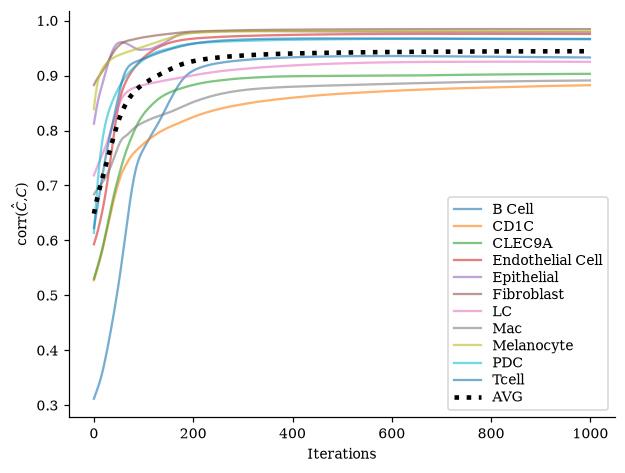

Gene weights optimized.
Training curve saved.


In [46]:
# Deconomix draws its own figure inside fit(). The inline backend normally closes a
# figure once it has been displayed, which would leave nothing to save, so the setting
# is switched off for this cell only and restored at the end.
%config InlineBackend.close_figures = False
plt.close("all")

model = Deconomix(verbose=True)
model.fit(sc_references, n_mixtures=1000)

fit_fig = plt.gcf()
if fit_fig.get_axes():
    fit_fig.set_size_inches(7, 5)
    fit_fig.axes[0].set_title("Gene-weight optimisation: correlation per cell type")
    save_fig(fit_fig, "11_dtd_training_curve")
    print("Training curve saved.")
else:
    print("No open figure found.")

plt.close("all")
%config InlineBackend.close_figures = True

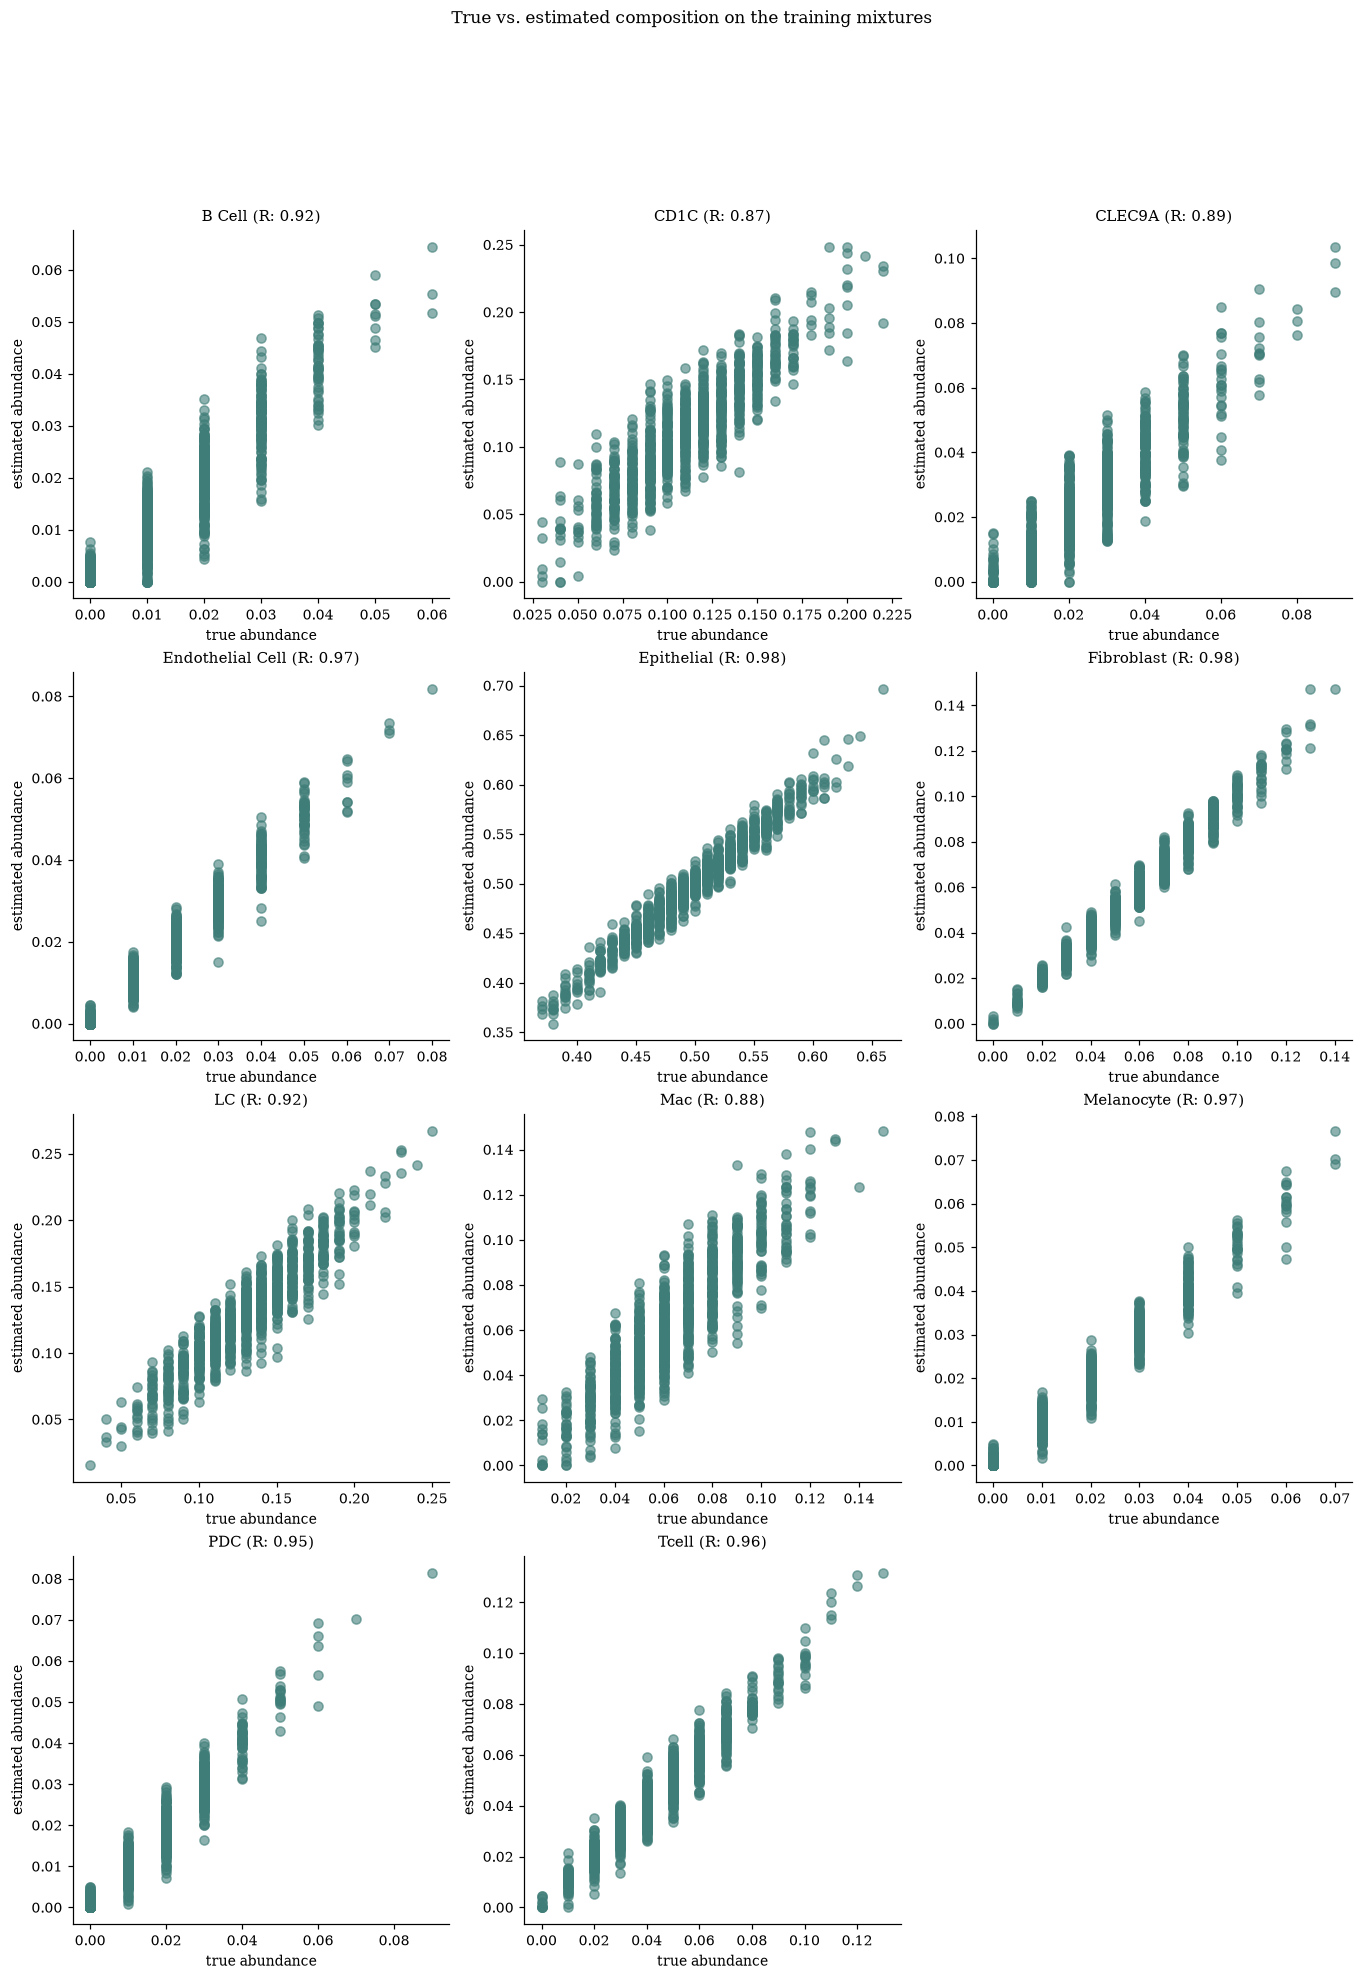

Correlation panel saved.

Fibroblast          0.983
Epithelial          0.977
Melanocyte          0.973
Endothelial Cell    0.968
Tcell               0.959
PDC                 0.954
B Cell              0.922
LC                  0.918
CLEC9A              0.890
Mac                 0.883
CD1C                0.867
dtype: float64


In [47]:
# Same arrangement as the previous cell: plot_corr draws the figure itself.
%config InlineBackend.close_figures = False
plt.close("all")

C_train_est = calculate_estimated_composition(model.X_ref, model.Y_train, model.gamma)
train_corr = plot_corr(model.C_train, C_train_est,
                       title="True vs. estimated composition on the training mixtures",
                       color="#3f7d78")

corr_fig = plt.gcf()
if corr_fig.get_axes():
    save_fig(corr_fig, "12_training_correlation")
    print("Correlation panel saved.")

plt.close("all")
%config InlineBackend.close_figures = True

print()
print(train_corr.sort_values(ascending=False).round(3))

The loss curve falls steeply and then flattens, so the optimisation has converged and
more iterations would not change the result.

All eleven cell types are recovered with a correlation above 0.85, and the weakest are
CD1C and macrophages, which is what the similarity of their reference profiles led us
to expect. The strongest are fibroblasts and epithelial cells, the two types with the
most distinct profiles.

These numbers describe the training data, not new data. They show that the model
learned the task it was given, but they say nothing about how well it transfers to the
section, which was measured on a different platform and contains cell types that are
not in the reference at all. No held-out test set is available here, because the true
composition of the spots is unknown. The results of the next step therefore have to be
judged by whether they agree with the tissue biology rather than by a correlation
against a ground truth.

In [48]:
# The section, on the same 2000 genes in the same order, normalized and on a linear
# scale. This is the matrix the trained model is applied to.
st_norm = np.asarray(to_dense(adata.layers["norm_counts"]))
bulk_df = pd.DataFrame(st_norm, index=adata.obs_names, columns=adata.var_names).T
bulk_df = bulk_df.loc[selected_genes]
bulk_df.index.name = "gene"

assert list(bulk_df.index) == list(X.index), "Gene order differs between bulk_df and X"
print("bulk_df:", bulk_df.shape, "(gene x spot)")

bulk_df: (2000, 604) (gene x spot)


In [49]:
model.predict(bulk_df, model="Deconomix")

C_est = model.C_est
print("Estimated composition:", C_est.shape, "(cell type x spot)")
print(f"Per-spot totals range from {C_est.sum(axis=0).min():.3f} to {C_est.sum(axis=0).max():.3f}")
C_est.head()

Calculating C_est with optimized gene weights.
Estimated composition: (11, 604) (cell type x spot)
Per-spot totals range from 0.744 to 2.002


,10x16,10x18,10x20,10x22,10x24,10x26,10x28,10x30,10x32,10x36,...,8x22,8x28,8x36,9x19,9x21,9x23,9x25,9x27,9x29,9x35
celltype,,,,,,,,,,,,,,,,,,,,,
B Cell,0.020038,0.000000,0.000000,0.000000,0.000000,0.009496,0.000000,0.000000,0.000000,0.000000,...,0.006489,0.274679,0.023346,0.000000,0.000000,0.000000,0.173921,0.044574,0.011471,0.000000
CD1C,0.389440,0.105149,0.177870,0.100872,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.215361,0.056844,0.000000,0.155807,0.037243,0.082973,0.227454,0.154919,0.094303,0.225907
CLEC9A,0.000000,0.006904,0.000000,0.000000,0.013537,0.000000,0.104097,0.091332,0.005770,0.262296,...,0.000000,0.000000,0.199466,0.000000,0.025291,0.000000,0.000000,0.198859,0.000000,0.058184
Endothelial Cell,0.030671,0.040282,0.011286,0.020812,0.335115,0.117678,0.092313,0.151606,0.194245,0.107034,...,0.018627,0.058386,0.022337,0.102228,0.013782,0.019129,0.096025,0.258314,0.180280,0.152608
Epithelial,0.691357,0.865764,0.834596,0.946648,0.024764,0.150259,0.000000,0.389362,0.156335,0.394736,...,0.808564,0.262136,0.446812,0.583775,0.652991,0.883419,0.292733,0.164865,0.260603,0.360713


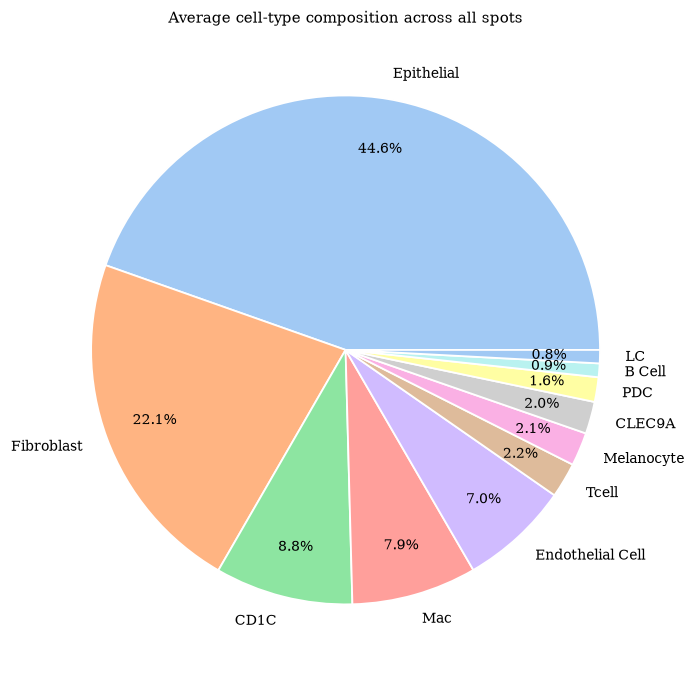

celltype
Epithelial          0.538
Fibroblast          0.266
CD1C                0.106
Mac                 0.096
Endothelial Cell    0.084
Tcell               0.027
Melanocyte          0.026
CLEC9A              0.025
PDC                 0.019
B Cell              0.010
LC                  0.010
dtype: float64


In [50]:
mean_abundance = C_est.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(mean_abundance.values,
       labels=mean_abundance.index,
       autopct="%1.1f%%",
       pctdistance=0.8,
       colors=sns.color_palette("pastel", len(mean_abundance)),
       textprops={"fontsize": 9},
       wedgeprops={"edgecolor": "white", "linewidth": 1.2})
ax.set_title("Average cell-type composition across all spots")

plt.tight_layout()
save_fig(fig, "13_mean_composition_pie")
plt.show()

print(mean_abundance.round(3))

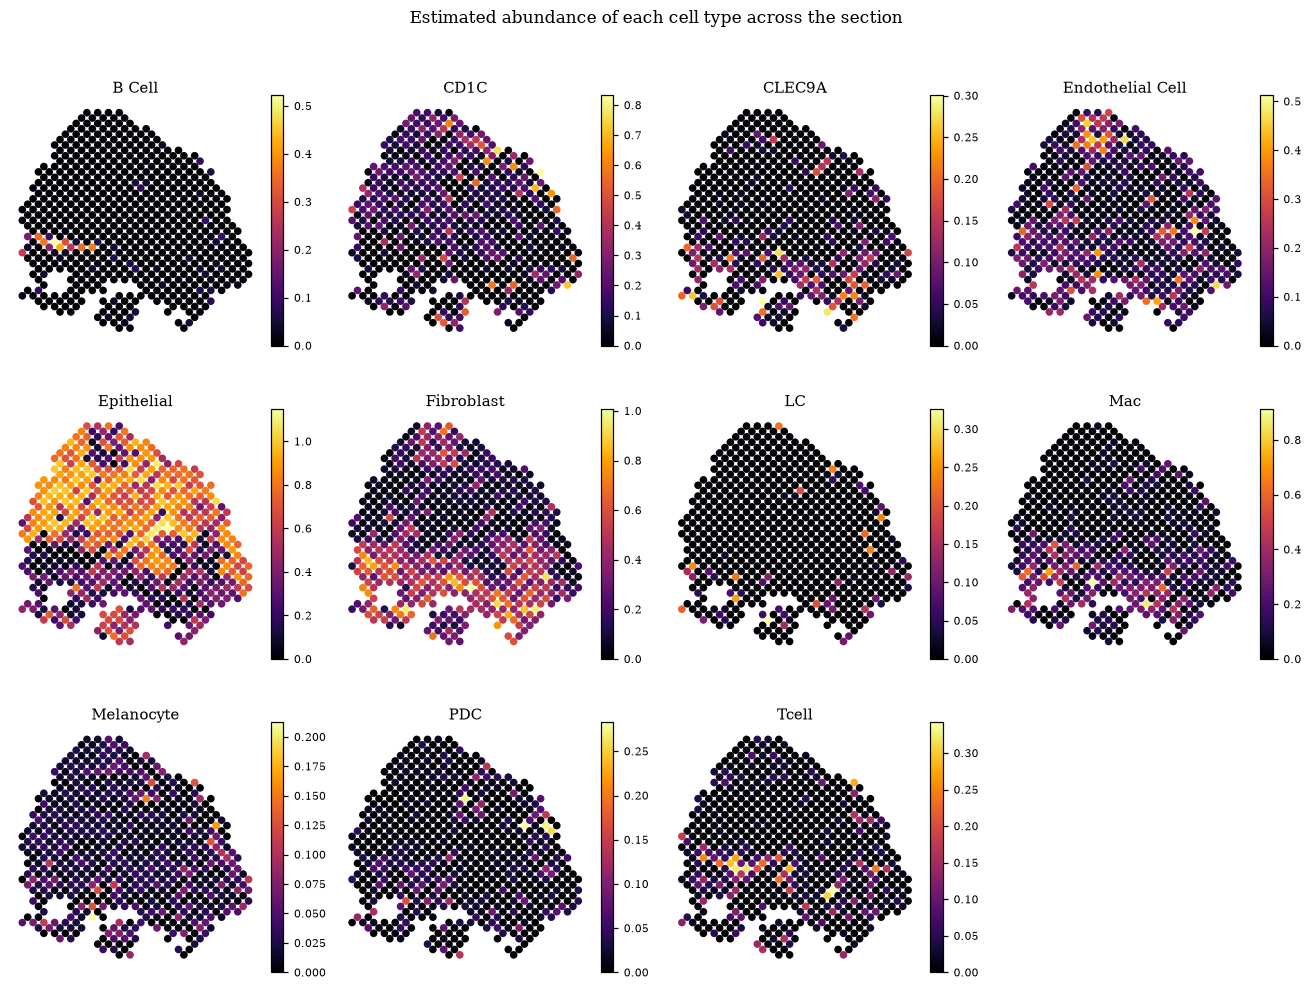

In [51]:
def plot_celltype_spatial(composition, ncols=4, title=None, cmap="inferno"):
    """One map of the section per cell type, coloured by estimated abundance."""
    celltypes = composition.index.tolist()
    nrows = int(np.ceil(len(celltypes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 3.0))
    axes = np.atleast_1d(axes).ravel()

    for ax, celltype in zip(axes, celltypes):
        spatial_scatter(composition.loc[celltype].values, ax=ax,
                        title=celltype, cmap=cmap, size=25)
    for ax in axes[len(celltypes):]:
        ax.set_visible(False)

    if title:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()
    return fig


fig = plot_celltype_spatial(C_est, title="Estimated abundance of each cell type across the section")
save_fig(fig, "14_spatial_celltypes")
plt.show()

In [52]:
# The maps above are dominated by exact zeros for the less abundant cell types. The
# non-negativity constraint of the fit produces these, so the extent is quantified
# here rather than left to the eye.
sparsity = pd.DataFrame({
    "mean estimate": C_est.mean(axis=1),
    "% of spots at zero": 100 * (C_est == 0).mean(axis=1),
    "max estimate": C_est.max(axis=1),
}).sort_values("mean estimate", ascending=False).round(2)

sparsity

,mean estimate,% of spots at zero,max estimate
celltype,,,
Epithelial,0.54,5.30,1.15
Fibroblast,0.27,0.83,1.01
CD1C,0.11,35.93,0.83
Mac,0.10,33.94,0.91
Endothelial Cell,0.08,8.77,0.51
Tcell,0.03,50.17,0.34
Melanocyte,0.03,15.56,0.21
CLEC9A,0.02,62.25,0.30
PDC,0.02,35.26,0.28


### 2.5 Results

Epithelial cells are the largest component and fibroblasts the second, and the two
occupy complementary parts of the section: epithelial cells across the upper two
thirds, fibroblasts along the lower third and the lower left. This is the same
tumour–stroma division that the co-expression analysis in Week 1 found from twenty
genes, now recovered from cell-type composition instead. Neither the reference nor
the deconvolution uses the position of a spot, so the fact that the estimates form
connected regions rather than a speckled pattern is a genuine check on the method.

The maps of the remaining cell types look very different. Most spots are estimated at
exactly zero, and the signal is carried by scattered individual spots. This follows
from the model: the fit is constrained to non-negative values, so a contribution that
would otherwise come out negative is set to zero instead. For a cell type that makes
up a few percent of the tissue, this produces many exact zeros rather than small
positive values. The estimates for these types should therefore be read as indicating
where a cell type is concentrated, not as a continuous abundance across the section.

Endothelial cells, macrophages and T cells have their non-zero spots mainly in the
lower, fibroblast-rich part of the section. This matches the structure of skin, where
vessels and resident immune cells sit in the dermis, and it is consistent with the
report by Ji et al. that the stroma bordering the tumour edge is enriched for
endothelial cells and cancer-associated fibroblasts.

One result contradicts expectation and is worth stating plainly. CD1C is estimated at
moderate levels across much of the upper, epithelial region, while Langerhans cells
are estimated at almost zero everywhere. Biologically the reverse would be expected,
since Langerhans cells are the resident dendritic cells of the epidermis whereas CD1C+
dendritic cells are mainly dermal. The likely reason was measured before the model was
fitted: the reference profiles of CD1C, Langerhans cells, CLEC9A and macrophages
correlate above 0.93 with each other. When two profiles are nearly identical, the fit
can divide their shared signal between them in almost any way without changing the
quality of the fit, so the individual estimates are unstable even though their sum is
not. The same four types are the ones with the lowest correlations on the training
mixtures. The myeloid estimates are therefore interpreted here only as a combined
signal, and the split between the individual dendritic-cell types is not used.

Two further points apply to all the maps. The estimates are not constrained to sum to
one, so the per-spot totals vary and contain a scaling component as well as a
composition; this is corrected at the start of Week 3. And the epithelial class covers
all keratinocytes, so a spot dominated by normal epidermis and a spot dominated by
tumour both appear simply as epithelial.

In [53]:
C_est.to_pickle(PROC_DIR / "C_est.pkl")
print("Estimated compositions written to", PROC_DIR / "C_est.pkl")

Estimated compositions written to Data\processed\C_est.pkl


In [54]:
# Small, human-readable exports for the report. The large intermediate matrices stay
# as pickles, since they are regenerated by this notebook and are not tracked in git.
X.to_csv(PROC_DIR / "X_reference.csv")
C_est.to_csv(PROC_DIR / "C_est.csv")
sparsity.to_csv(PROC_DIR / "celltype_sparsity.csv")
print("CSV exports written.")

CSV exports written.


## 3. Week 3 — Downstream analysis

Tissue is not homogeneous. In one area keratinocytes form a dense mass, elsewhere
fibroblasts and vessels form a network, and in another immune cells gather. These
recurring associations of cell types are called niches here.

Week 2 produced an estimated composition for every spot. This part groups the spots by
how similar their compositions are, describes what distinguishes the resulting groups
transcriptionally, and asks which biological processes those genes belong to.

The grouping deliberately ignores position. The clustering sees only composition
vectors and does not know whether two spots are neighbours or lie at opposite ends of
the section. This makes the result a test: if the estimates were mostly noise, the
groups would be scattered randomly over the slide. If they reflect real tissue
organisation, spots with similar compositions should also lie close together.

In [55]:
# Deconomix does not force the estimates of a spot to sum to one, so the per-spot
# totals carry a scaling component as well as a composition. Rescaling each spot to sum
# to one makes the clustering depend only on the relative mixture of cell types, which
# is what a niche is meant to describe.
C = C_est.T.copy()                                   # spots x cell types
assert list(C.index) == list(adata.obs_names), "Spot order differs from adata"

C_prop = C.div(C.sum(axis=1), axis=0)

print(f"Raw per-spot totals: {C.sum(axis=1).min():.3f} - {C.sum(axis=1).max():.3f}")
print(f"After rescaling:     {C_prop.sum(axis=1).min():.3f} - {C_prop.sum(axis=1).max():.3f}")
print("\nMean proportion per cell type:")
print(C_prop.mean().sort_values(ascending=False).round(3))

Raw per-spot totals: 0.744 - 2.002
After rescaling:     1.000 - 1.000

Mean proportion per cell type:
celltype
Epithelial          0.458
Fibroblast          0.217
CD1C                0.084
Mac                 0.076
Endothelial Cell    0.070
Tcell               0.022
Melanocyte          0.021
CLEC9A              0.019
PDC                 0.016
B Cell              0.008
LC                  0.008
dtype: float64


k = 2:  inertia =  31.891   silhouette = 0.513
k = 3:  inertia =  24.549   silhouette = 0.375
k = 4:  inertia =  21.820   silhouette = 0.319
k = 5:  inertia =  19.687   silhouette = 0.304
k = 6:  inertia =  17.868   silhouette = 0.279
k = 7:  inertia =  16.195   silhouette = 0.284
k = 8:  inertia =  15.085   silhouette = 0.280


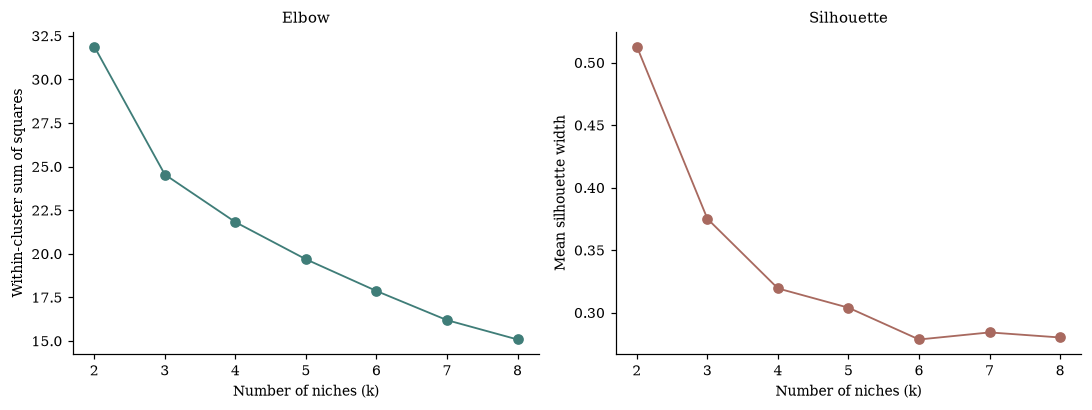

In [56]:
K_RANGE = range(2, 9)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(C_prop.values)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(C_prop.values, km.labels_))
    print(f"k = {k}:  inertia = {km.inertia_:7.3f}   silhouette = {silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].plot(list(K_RANGE), inertias, marker="o", color="#3f7d78", linewidth=1.2)
axes[0].set_xlabel("Number of niches (k)")
axes[0].set_ylabel("Within-cluster sum of squares")
axes[0].set_title("Elbow")

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="#a8695f", linewidth=1.2)
axes[1].set_xlabel("Number of niches (k)")
axes[1].set_ylabel("Mean silhouette width")
axes[1].set_title("Silhouette")

for ax in axes:
    ax.set_xticks(list(K_RANGE))

plt.tight_layout()
save_fig(fig, "15_niche_k_selection")
plt.show()

In [57]:
# The two criteria above measure how well separated the clusters are, not whether they
# correspond to anything. The composition profiles are inspected directly to see what
# each choice of k actually produces.
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(C_prop.values)
    summary = C_prop.groupby(km.labels_).mean().round(3)
    summary.insert(0, "n_spots", pd.Series(km.labels_).value_counts().sort_index().values)
    print(f"===== k = {k} =====")
    print(summary.to_string())
    print()

===== k = 2 =====
celltype  n_spots  B Cell   CD1C  CLEC9A  Endothelial Cell  Epithelial  Fibroblast     LC    Mac  Melanocyte    PDC  Tcell
0             267   0.017  0.055   0.035             0.111       0.185       0.379  0.011  0.132       0.021  0.018  0.037
1             337   0.002  0.106   0.007             0.038       0.674       0.089  0.006  0.032       0.021  0.014  0.011

===== k = 3 =====
celltype  n_spots  B Cell   CD1C  CLEC9A  Endothelial Cell  Epithelial  Fibroblast     LC    Mac  Melanocyte    PDC  Tcell
0             231   0.001  0.096   0.003             0.026       0.752       0.059  0.002  0.026       0.019  0.009  0.007
1             213   0.018  0.041   0.038             0.117       0.142       0.409  0.011  0.144       0.021  0.018  0.041
2             160   0.006  0.122   0.019             0.071       0.454       0.190  0.012  0.058       0.025  0.022  0.020

===== k = 4 =====
celltype  n_spots  B Cell   CD1C  CLEC9A  Endothelial Cell  Epithelial  Fibroblast 

### 3.1 Choosing the number of niches

The silhouette score is highest at k = 2 (0.51) and falls steadily as k increases, so
on that criterion alone two niches would be chosen. Four are used here instead, for two
reasons.

At k = 2 the split is simply epithelial against everything else. That division is real,
but it is already visible in the raw expression data from Week 1 and adds nothing. It
also treats the stroma as a single block, even though the composition estimates
separate a fibroblast-dominated part from a macrophage-dominated one as soon as k = 4.

A silhouette score also rewards compact, well separated clusters, which is not what
tissue looks like. Compartments in a section meet at boundaries, and spots on a
boundary are genuinely intermediate. A criterion that penalises intermediate points
will always favour fewer clusters here, so it is a poor guide on its own.

The choice of k = 4 is therefore made on the composition profiles and then tested
independently in two ways: whether the four groups occupy sensible positions relative to
one another on the slide, and whether they differ in gene expression as well as in
composition.

In [58]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=50, random_state=RANDOM_STATE).fit(C_prop.values)
cluster_ids = pd.Series(kmeans.labels_, index=C_prop.index)
profiles = C_prop.groupby(cluster_ids).mean()

# The niche names are defined once here and reused everywhere else. They must not
# contain a forward slash, because the differential expression results are stored
# under these names inside the HDF5 file and a slash is a path separator there.
TUMOUR      = "Tumour and epidermis"
INTERFACE   = "Epithelial-stromal interface"
FIBROBLAST  = "Fibroblast-rich stroma"
INFLAMMATORY = "Inflammatory stroma"

NICHE_ORDER = [TUMOUR, INTERFACE, FIBROBLAST, INFLAMMATORY]
NICHE_COLORS = {TUMOUR:       "#3f7d78",
                INTERFACE:    "#7a95c4",
                FIBROBLAST:   "#c9a227",
                INFLAMMATORY: "#a8695f"}

# k-means numbers its clusters arbitrarily, so names are derived from the composition
# profiles themselves. This keeps the labelling stable if the notebook is re-run.
remaining = list(profiles.index)
names = {}

for celltype, label in [("Epithelial", TUMOUR),
                        ("Mac",        INFLAMMATORY),
                        ("Fibroblast", FIBROBLAST)]:
    winner = profiles.loc[remaining, celltype].idxmax()
    names[winner] = label
    remaining.remove(winner)
names[remaining[0]] = INTERFACE

adata.obs["niche"] = pd.Categorical(cluster_ids.map(names).loc[adata.obs_names].values,
                                    categories=NICHE_ORDER, ordered=True)
labels = adata.obs["niche"].astype(str).values

niche_profiles = C_prop.groupby(labels, observed=True).mean().loc[NICHE_ORDER]
niche_profiles.insert(0, "n_spots",
                      adata.obs["niche"].value_counts().loc[NICHE_ORDER].values)

print(niche_profiles.round(3).to_string())

celltype                      n_spots  B Cell   CD1C  CLEC9A  Endothelial Cell  Epithelial  Fibroblast     LC    Mac  Melanocyte    PDC  Tcell
Tumour and epidermis              226   0.001  0.094   0.003             0.026       0.755       0.058  0.002  0.027       0.019  0.009  0.006
Epithelial-stromal interface      155   0.007  0.122   0.019             0.069       0.470       0.182  0.012  0.052       0.026  0.022  0.020
Fibroblast-rich stroma            114   0.013  0.083   0.029             0.145       0.166       0.439  0.008  0.054       0.021  0.018  0.024
Inflammatory stroma               109   0.022  0.009   0.044             0.085       0.130       0.365  0.014  0.236       0.020  0.019  0.056


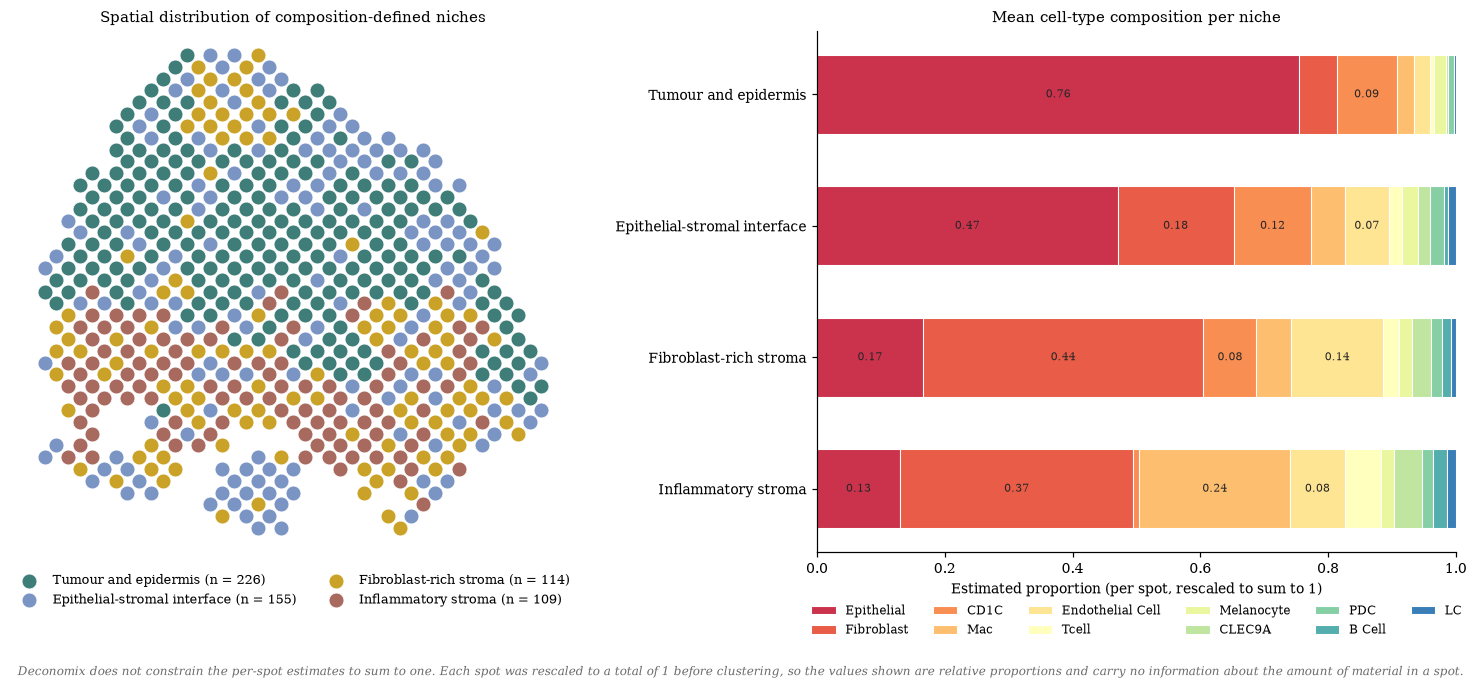

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         gridspec_kw={"width_ratios": [1, 1.15]})

# No positional information entered the clustering, so spatial coherence in this map is
# evidence of tissue organisation rather than a property of the method.
for name in NICHE_ORDER:
    mask = labels == name
    axes[0].scatter(coordinates[mask, 0], coordinates[mask, 1],
                    s=95, c=NICHE_COLORS[name], marker="o",
                    edgecolors="white", linewidth=0.5,
                    label=f"{name} (n = {mask.sum()})")

axes[0].set_aspect("equal")
axes[0].invert_yaxis()
axes[0].set_xticks([]); axes[0].set_yticks([])
for spine in axes[0].spines.values():
    spine.set_visible(False)
axes[0].set_title("Spatial distribution of composition-defined niches")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.02),
               frameon=False, fontsize=8.5, ncol=2)

celltype_order = C_prop.mean().sort_values(ascending=False).index
bars = niche_profiles[celltype_order]
bottom = np.zeros(len(bars))

for celltype, color in zip(celltype_order, sns.color_palette("Spectral", len(celltype_order))):
    values = bars[celltype].values
    axes[1].barh(range(len(bars)), values, left=bottom, height=0.6,
                 color=color, edgecolor="white", linewidth=0.7, label=celltype)
    for i, (v, b) in enumerate(zip(values, bottom)):
        if v > 0.06:
            axes[1].text(b + v / 2, i, f"{v:.2f}", ha="center", va="center",
                         fontsize=7.5, color="0.15")
    bottom += values

axes[1].set_yticks(range(len(bars)))
axes[1].set_yticklabels(bars.index)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Estimated proportion (per spot, rescaled to sum to 1)")
axes[1].set_title("Mean cell-type composition per niche")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.08),
               frameon=False, fontsize=8, ncol=6)

fig.text(0.5, -0.03,
         "Deconomix does not constrain the per-spot estimates to sum to one. Each spot was rescaled "
         "to a total of 1 before clustering, so the values shown are relative proportions and carry "
         "no information about the amount of material in a spot.",
         ha="center", fontsize=8, style="italic", color="0.42")

plt.tight_layout()
save_fig(fig, "16_niche_map_and_composition")
plt.show()

In [60]:
# A niche defined without coordinates can still be checked against them. A compartment
# should mostly border itself; a transition zone should border the compartments it lies
# between. Nearest neighbours on the checkerboard lattice are one step away in both
# coordinates.
from scipy.spatial import cKDTree

tree = cKDTree(coordinates)
neighbours = {i: [] for i in range(len(coordinates))}
for i, j in tree.query_pairs(r=1.5):
    neighbours[i].append(j)
    neighbours[j].append(i)

rows = []
for name in NICHE_ORDER:
    tally, total = Counter(), 0
    for i in np.where(labels == name)[0]:
        for j in neighbours[i]:
            tally[labels[j]] += 1
            total += 1
    rows.append({"niche": name,
                 "mean neighbours": total / (labels == name).sum(),
                 **{other: tally[other] / total for other in NICHE_ORDER}})

neighbour_table = pd.DataFrame(rows).set_index("niche")
print("Fraction of each niche's neighbouring spots belonging to each niche:\n")
print(neighbour_table.round(2).to_string())

Fraction of each niche's neighbouring spots belonging to each niche:

                              mean neighbours  Tumour and epidermis  Epithelial-stromal interface  Fibroblast-rich stroma  Inflammatory stroma
niche                                                                                                                                         
Tumour and epidermis                     3.85                  0.72                          0.19                    0.06                 0.03
Epithelial-stromal interface             3.50                  0.30                          0.39                    0.18                 0.12
Fibroblast-rich stroma                   3.64                  0.13                          0.24                    0.36                 0.27
Inflammatory stroma                      3.75                  0.07                          0.16                    0.28                 0.49


In [61]:
# The niches were defined from composition alone, but sequencing depth also varies
# across the section. Two things are checked: whether the niches differ in depth, and
# whether depth affects how concentrated a composition estimate is. A sparse profile
# gives the fit less to work with, so its weight tends to spread over more cell types.
concentration = C_prop.max(axis=1)
log_depth = np.log10(pd.Series(depth, index=adata.obs_names))

quality = pd.DataFrame({
    "total counts": depth,
    "genes detected": adata.obs["n_genes_by_counts"].values,
    "largest proportion": concentration.values,
    "niche": labels,
})

print(quality.groupby("niche", observed=True).median(numeric_only=True)
             .loc[NICHE_ORDER].round(2).to_string())

epithelial_rich = C_prop["Epithelial"] > 0.4
print("\nCorrelation between log depth and the largest proportion in a spot:")
print(f"  all spots:                            r = {log_depth.corr(concentration):.3f}")
print(f"  spots above 40 % epithelial (n = {epithelial_rich.sum()}):  "
      f"r = {log_depth[epithelial_rich].corr(concentration[epithelial_rich]):.3f}")

                              total counts  genes detected  largest proportion
niche                                                                         
Tumour and epidermis               19441.0          4913.5                0.76
Epithelial-stromal interface        2320.0          1155.0                0.48
Fibroblast-rich stroma              4119.0          2058.0                0.43
Inflammatory stroma                 4340.0          2246.0                0.37

Correlation between log depth and the largest proportion in a spot:
  all spots:                            r = 0.500
  spots above 40 % epithelial (n = 343):  r = 0.577


In [62]:
# The reference profiles of CD1C, LC, CLEC9A and macrophages correlate above 0.93, so
# the split between them is unstable while their sum is not. The niche profiles are
# therefore also reported with the four pooled.
MYELOID = ["CD1C", "LC", "CLEC9A", "Mac"]

pooled = C_prop.drop(columns=MYELOID)
pooled["Myeloid (pooled)"] = C_prop[MYELOID].sum(axis=1)

pooled_profiles = pooled.groupby(labels, observed=True).mean().loc[NICHE_ORDER]
pooled_profiles.insert(0, "n_spots",
                       adata.obs["niche"].value_counts().loc[NICHE_ORDER].values)

print("Niche profiles with the myeloid types pooled:\n")
print(pooled_profiles.round(3).to_string())
print("\nIndividual myeloid estimates, shown for comparison only:")
print(C_prop[MYELOID].groupby(labels, observed=True).mean().loc[NICHE_ORDER].round(3).to_string())

Niche profiles with the myeloid types pooled:

celltype                      n_spots  B Cell  Endothelial Cell  Epithelial  Fibroblast  Melanocyte    PDC  Tcell  Myeloid (pooled)
Tumour and epidermis              226   0.001             0.026       0.755       0.058       0.019  0.009  0.006             0.126
Epithelial-stromal interface      155   0.007             0.069       0.470       0.182       0.026  0.022  0.020             0.204
Fibroblast-rich stroma            114   0.013             0.145       0.166       0.439       0.021  0.018  0.024             0.174
Inflammatory stroma               109   0.022             0.085       0.130       0.365       0.020  0.019  0.056             0.303

Individual myeloid estimates, shown for comparison only:
celltype                       CD1C     LC  CLEC9A    Mac
Tumour and epidermis          0.094  0.002   0.003  0.027
Epithelial-stromal interface  0.122  0.012   0.019  0.052
Fibroblast-rich stroma        0.083  0.008   0.029  0.054
Inf

### 3.2 The four niches

The niches form spatially structured regions on the slide even though the clustering
never saw a coordinate. The tumour and epidermal niche occupies a connected area across
the upper part of the section and the two stromal niches lie together along the lower
part. Random estimates would produce a scattered map, so this is the clearest evidence
in the analysis that the composition estimates describe real tissue organisation.

The neighbour analysis makes this precise. Each niche mostly borders itself, and the
remaining values describe an ordering rather than a random arrangement. The tumour
niche almost never borders the stromal niches (9 % of its neighbours), and the
inflammatory niche almost never borders the tumour (7 %). The interface niche is the
only one that borders everything, with 30 % of its neighbours in the tumour niche and
30 % in the two stromal niches. The four niches therefore lie along an axis running
outwards from the epithelial mass: tumour and epidermis, then the interface, then the
fibroblast-rich stroma, then the inflammatory stroma.

The composition profiles follow the same axis. The tumour niche is dominated by
epithelial cells (0.76). The interface is intermediate in every cell type. The
fibroblast-rich niche is dominated by fibroblasts (0.44) and carries the highest
endothelial fraction of the four (0.15). The inflammatory niche has a similar fibroblast
content (0.37) but adds the largest myeloid fraction (0.30 pooled, mostly macrophages)
and the highest T-cell and B-cell fractions.

Two of these agree with what Ji et al. describe for these tumours. They report that the
stroma one spot away from the tumour leading edge is enriched for endothelial and
cancer-associated fibroblast transcripts, which they call a fibrovascular niche. The
fibroblast-rich niche found here has exactly that combination and sits exactly one step
out from the epithelial mass in the neighbour analysis. They also report that
fibroblasts, macrophages and regulatory T cells are most abundant at the tumour–stromal
margin while CD8 T cells are largely excluded from the tumour itself. The inflammatory
niche matches this: it is a mixed stromal and immune compartment rather than a pure
immune one, its T-cell fraction is the highest of the four, and the tumour niche's is
close to zero.

A direct comparison with their central result is not possible. Their leading-edge niche
is defined relative to the tumour-specific keratinocyte population, and the level-1
annotation used here pools all keratinocytes into one epithelial class, so no
tumour-specific state can be located.

The myeloid estimates need one qualification. Pooled, they behave sensibly: highest in
the inflammatory niche, lowest in the tumour niche. Split, they do not. The tumour and
epidermal niche is assigned a pooled myeloid fraction of 0.13, of which almost all goes
to CD1C and essentially none to Langerhans cells, although Langerhans cells are the
resident dendritic cells of the epidermis. The signal is in the right place but in the
wrong column, which is the behaviour predicted by the collinearity of these four
reference profiles. Only the pooled value is used below.

Finally, the niches differ in sequencing depth, and this has to be stated rather than
passed over. The tumour niche has a median of about 19,000 counts per spot against
2,500 to 4,300 for the other three. Part of this is expected, since the epithelial mass
is the most densely cellular part of the section. But it is not only that: even among
spots that are more than 40 % epithelial, log depth correlates with how concentrated the
composition estimate is at r = 0.58. A sparsely measured spot gives the fit less to work
with and its weight spreads over more cell types. The interface niche is the shallowest
of the four, so part of its intermediate composition reflects measurement sparsity
rather than genuinely mixed cellular content. Its position between the compartments
shows that it is not only that, but the two contributions cannot be separated here, and
this is carried into the discussion as a limitation.

In [63]:
# What distinguishes the niches transcriptionally. The Wilcoxon rank-sum test compares
# the ranks of a gene's expression in one niche against all other spots, so it makes no
# assumption about how the expression values are distributed. Testing every gene
# requires control of the false discovery rate, done here by Benjamini-Hochberg.
sc.tl.rank_genes_groups(adata, groupby="niche", method="wilcoxon",
                        layer="log_counts", use_raw=False, pts=True,
                        key_added="niche_de")

MIN_DETECTION = 0.10   # gene must be detected in at least 10 % of the niche's spots

niche_de = {}
for name in NICHE_ORDER:
    table = sc.get.rank_genes_groups_df(adata, group=name, key="niche_de")
    up = table[(table["pvals_adj"] < 0.05) &
               (table["logfoldchanges"] > 0.25) &
               (table["pct_nz_group"] > MIN_DETECTION)]
    down = table[(table["pvals_adj"] < 0.05) & (table["logfoldchanges"] < -0.25)]

    # The order is the one scanpy produces, by the test statistic. Ranking by fold
    # change instead would put genes detected in a handful of spots at the top, since a
    # ratio computed from near-zero values is large but not meaningful.
    niche_de[name] = up

    print(f"===== {name}  ({(labels == name).sum()} spots) =====")
    print(f"Upregulated: {len(up)}   Downregulated: {len(down)}")
    print("Top 20 up:", ", ".join(up["names"].head(20)))
    print()

===== Tumour and epidermis  (226 spots) =====
Upregulated: 5810   Downregulated: 330
Top 20 up: DSP, FABP5, PERP, PKP1, LY6D, GJB2, YWHAZ, GJB6, SERPINB5, DSC2, JUP, AQP3, DSC3, LAD1, CSTB, TACSTD2, SPRR1A, DSG3, SPRR1B, DSG1

===== Epithelial-stromal interface  (155 spots) =====
Upregulated: 8   Downregulated: 1611
Top 20 up: KRT6A, KRT6B, KRT5, KRT6C, COL17A1, S100A2, KRT14, SFN

===== Fibroblast-rich stroma  (114 spots) =====
Upregulated: 233   Downregulated: 1655
Top 20 up: COL1A1, COL1A2, COL3A1, AEBP1, SPARC, DCN, COL6A2, IGFBP4, VIM, NNMT, LGALS1, COL6A1, CD63, THY1, C1R, FSTL1, SERPINF1, FTL, S100A4, FTH1

===== Inflammatory stroma  (109 spots) =====
Upregulated: 397   Downregulated: 1008
Top 20 up: FTL, CD74, HLA.DRA, PSAP, HLA.B, HLA.DPA1, RNASE1, CD14, NNMT, IGFBP4, C1R, FTH1, DCN, TIMP1, CTSB, FBLN1, MMP2, COL1A2, SERPINF1, COL3A1



### 3.3 What the niches express

Genes are ranked by the test statistic rather than by fold change. On sparse count
data a fold change computed from near-zero values is large without being meaningful,
and ranking by it fills the top of the list with genes detected in a handful of spots.
Genes detected in fewer than 10 % of a niche's spots are also excluded for the same
reason.

Three of the four niches have a clear signature.

The tumour and epidermal niche is defined by desmosomal and cornified-envelope genes
(DSP, PKP1, PERP, JUP, DSC2, DSC3, DSG1, DSG3, SPRR1A, SPRR1B, LAD1) together with
keratins, FABP5 and TACSTD2. These are the genes of keratinocytes attached to one
another and undergoing differentiation, which is what an epidermal or keratinocyte
tumour mass consists of.

The fibroblast-rich niche is defined by collagens and matrix proteins (COL1A1, COL1A2,
COL3A1, COL6A1, COL6A2, DCN, SPARC, AEBP1, IGFBP4, THY1, FSTL1), the programme of
fibroblasts producing extracellular matrix. It also carries vascular genes, among them
ECSCR, an endothelial cell surface protein, together with CTGF, TAGLN and MGP.

The inflammatory niche is defined by macrophage genes (CD163, CD14, LILRB2, LILRB4,
SIGLEC1, FCGR1A, FCGR1B, CD209, FCN1) and MHC class II transcripts (CD74, HLA-DRA,
HLA-DPA1), which matches its high pooled myeloid content. Two further groups appear
alongside them. GZMA and NKG7 are granule genes of cytotoxic lymphocytes, and CCL18,
CCL19 and CCL5 are chemokines that recruit them. And MMP2, TIMP1, FBLN1, DCN, COL1A2
and COL3A1 place matrix remodelling in the same niche. This is therefore a mixed
stromal and immune compartment rather than a separate immune infiltrate, which is what
Ji et al. describe for the tumour–stromal margin of these tumours.

The interface niche yields only eight significant genes, against hundreds or thousands
for the others, and those genes are ordinary basal and activated keratinocyte markers
(KRT5, KRT6A, KRT6B, KRT6C, KRT14, COL17A1, S100A2, SFN) rather than a programme of its
own. This is what a transition zone looks like: spots on a boundary contain a mixture
of both neighbouring compartments, so their expression lies between the two and few
genes are specifically higher there than everywhere else.

The counts themselves should not be compared between niches. The numbers of
downregulated genes are large everywhere (1,008 to 1,655) except in the tumour niche
(330), and the tumour niche is the only one with far more upregulated than
downregulated genes. This follows from the depth difference described above rather
than from biology: spots with fewer counts detect fewer genes, so most genes rank
lower in them, and the deepest niche appears higher in almost everything. The identity
of the top-ranked genes is unaffected and remains interpretable, but the totals are as
much a property of the measurement as of the tissue.

In [64]:
GENE_SETS = ["GO_Biological_Process_2023", "Reactome_2022"]
MAX_GENES = 300

# Over-representation analysis weights every submitted gene equally and ignores effect
# size, so a list of several thousand genes returns significant terms for almost any
# process. Long lists are capped at the most significantly enriched genes; shorter
# lists are passed unchanged. The background is the set of genes actually tested.
niche_gene_sets = {}
for name in NICHE_ORDER:
    genes = niche_de[name]["names"].head(MAX_GENES).tolist()
    # Gene names were sanitized when the AnnData was built (HLA-DRA became HLA.DRA).
    niche_gene_sets[name] = [g.replace(".", "-") for g in genes]
    print(f"{name:30s} {len(niche_de[name]):5d} significant -> {len(genes):4d} submitted")

background = [g.replace(".", "-") for g in adata.var_names]
print(f"\nBackground: {len(background)} genes")

Tumour and epidermis            5810 significant ->  300 submitted
Epithelial-stromal interface       8 significant ->    8 submitted
Fibroblast-rich stroma           233 significant ->  233 submitted
Inflammatory stroma              397 significant ->  300 submitted

Background: 14889 genes


In [65]:
enrichment = {}

for name in NICHE_ORDER:
    result = gp.enrichr(gene_list=niche_gene_sets[name], gene_sets=GENE_SETS,
                        background=background, organism="human", outdir=None).results
    result = result[result["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value").copy()
    result["n_genes"] = result["Genes"].str.split(";").str.len()
    result["term"] = (result["Term"].str.split(" R-HSA-").str[0]
                                    .str.split(r" \(GO:").str[0].str.strip())
    enrichment[name] = result

    print(f"===== {name}  ({len(niche_gene_sets[name])} genes submitted) =====")
    if result.empty:
        print("  No terms enriched at q < 0.05\n")
        continue
    print(f"  {len(result)} terms at q < 0.05")
    for _, row in result.drop_duplicates("term").head(6).iterrows():
        source = "GO" if row["Gene_set"].startswith("GO") else "Reactome"
        print(f"  [{source:8s}] {row['term'][:52]:52s} n = {row['n_genes']:3d}  q = {row['Adjusted P-value']:.1e}")
    print()

===== Tumour and epidermis  (300 genes submitted) =====
  44 terms at q < 0.05
  [Reactome] Keratinization                                       n =  26  q = 4.6e-19
  [Reactome] Formation Of Cornified Envelope                      n =  21  q = 5.4e-18
  [GO      ] Epidermis Development                                n =  18  q = 1.3e-11
  [GO      ] Keratinocyte Differentiation                         n =  14  q = 2.3e-11
  [GO      ] Epidermal Cell Differentiation                       n =  15  q = 2.3e-11
  [GO      ] Skin Development                                     n =  14  q = 1.3e-08

===== Epithelial-stromal interface  (8 genes submitted) =====
  21 terms at q < 0.05
  [Reactome] Keratinization                                       n =   5  q = 7.9e-09
  [GO      ] Intermediate Filament Organization                   n =   4  q = 3.0e-07
  [GO      ] Epidermis Development                                n =   3  q = 1.2e-04
  [GO      ] Supramolecular Fiber Organization      

In [66]:
# The inflammatory niche returns T-cell terms although macrophages dominate its
# estimated composition. The genes behind those terms are listed to see which cells
# they point to.
result = enrichment[INFLAMMATORY]
for term in ["Positive Regulation Of T Cell Activation", "Phosphorylation Of CD3"]:
    match = result[result["term"].str.contains(term, regex=False)]
    if len(match):
        print(match.iloc[0]["term"])
        print(" ", match.iloc[0]["Genes"].replace(";", ", "))
        print()

Positive Regulation Of T Cell Activation
  HLA-DRB5, XBP1, CD81, HLA-A, THY1, LILRB2, AIF1, HLA-DMA, PTPRC, HLA-DMB, CD209, CCL5, HLA-DRA, NCKAP1L, CCL19, B2M, HLA-DQA2, HLA-DQA1, HLA-DRB1, HLA-DPA1

Phosphorylation Of CD3 And TCR Zeta Chains
  HLA-DRB5, PTPRC, HLA-DRA, HLA-DQA2, HLA-DQA1, HLA-DRB1, HLA-DPA1



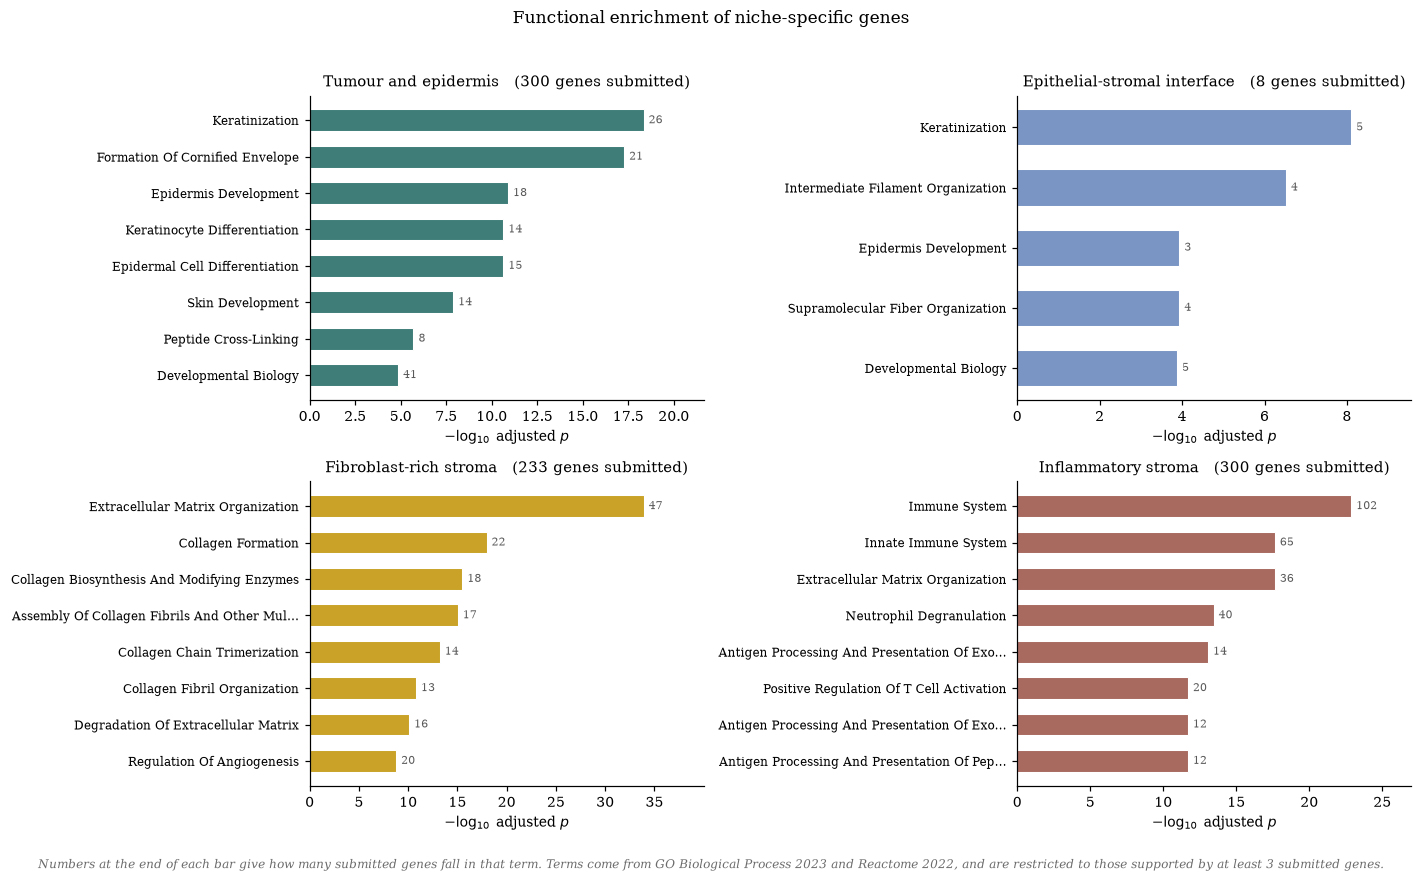

In [67]:
TOP_N = 8
MIN_TERM_GENES = 3

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, name in zip(axes.ravel(), NICHE_ORDER):
    result = enrichment[name]

    # GO and Reactome describe overlapping processes, so the same term can appear twice.
    # Deduplicating keeps the more significant version and still fills the panel. Terms
    # supported by only one or two genes pass the significance threshold but cannot be
    # interpreted, so they are dropped as well.
    shown = result[result["n_genes"] >= MIN_TERM_GENES].drop_duplicates("term")

    if shown.empty:
        ax.text(0.5, 0.5, f"No terms with {MIN_TERM_GENES} or more genes\nat q < 0.05",
                ha="center", va="center", fontsize=11, color="0.45",
                transform=ax.transAxes)
        ax.set_title(name)
        ax.axis("off")
        continue

    top = shown.head(TOP_N).copy()
    top["neglog_q"] = -np.log10(top["Adjusted P-value"])
    top = top.iloc[::-1]

    y = np.arange(len(top))
    ax.barh(y, top["neglog_q"], height=0.6, color=NICHE_COLORS[name],
            edgecolor="white", linewidth=0.7)

    for i, (value, n) in enumerate(zip(top["neglog_q"], top["n_genes"])):
        ax.text(value + top["neglog_q"].max() * 0.015, i, f"{n}",
                va="center", fontsize=7.5, color="0.35")

    ax.set_yticks(y)
    ax.set_yticklabels([t if len(t) <= 44 else t[:42] + "…" for t in top["term"]],
                       fontsize=8)
    ax.set_xlabel("$-\\log_{10}$ adjusted $p$")
    ax.set_xlim(0, top["neglog_q"].max() * 1.18)
    ax.set_title(f"{name}   ({len(niche_gene_sets[name])} genes submitted)", fontsize=10)

fig.suptitle("Functional enrichment of niche-specific genes")
fig.text(0.5, 0.005,
         f"Numbers at the end of each bar give how many submitted genes fall in that term. "
         f"Terms come from GO Biological Process 2023 and Reactome 2022, and are restricted "
         f"to those supported by at least {MIN_TERM_GENES} submitted genes.",
         ha="center", fontsize=8, style="italic", color="0.42")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
save_fig(fig, "17_niche_enrichment")
plt.show()

### 3.4 Functional interpretation

The enrichment results confirm the reading of the gene lists and add two things the
lists alone do not give.

The tumour and epidermal niche is enriched for epidermis development, keratinocyte
differentiation and formation of the cornified envelope. This is the expected programme
of the cell type that dominates the niche, so here the enrichment mainly confirms that
the composition estimates and the expression data agree.

The fibroblast-rich niche gives the most significant terms of the whole analysis:
extracellular matrix organisation, collagen formation and collagen fibril
organisation. Alongside them, and this is the first of the two additions, it is also
enriched for regulation of angiogenesis. The niche is therefore not merely
fibroblast-rich but fibrovascular, which agrees with it carrying the highest estimated
endothelial fraction of the four niches and with its position one step outward from the
epithelial mass in the neighbour analysis. Ji et al. describe exactly such a
fibrovascular niche in the stroma bordering the tumour leading edge, defined by
enrichment of endothelial and cancer-associated fibroblast transcripts. Two independent
lines of evidence here, the composition estimates and the functional enrichment of the
expression data, point to the same structure.

The inflammatory niche provides the second addition. Alongside the innate immune terms
expected from its myeloid content, it is enriched for antigen processing and
presentation and for T-cell activation. The genes behind these terms explain why: they
combine T-cell components (CD3D, PTPRC, LCK, CD6) with a large block of MHC class II
genes (HLA-DRA, HLA-DRB1, HLA-DRB5, HLA-DPA1, HLA-DQA1, HLA-DQA2, HLA-DMA, HLA-DMB) and
the chemokines CCL5 and CCL19. The terms describe an interaction between
antigen-presenting cells and T cells rather than T-cell infiltration on its own, and
they support the small T-cell fraction the deconvolution estimated for this niche.
Extracellular matrix organisation is also enriched here, confirming that the niche mixes
immune and stromal programmes. This is a result that neither the composition estimates
nor the expression data would have produced alone.

The interface niche returns enriched terms as well, but they should be read with
caution. Only eight genes were submitted, all keratins or keratinocyte structural
genes, so the terms recovered are keratinisation and intermediate filament
organisation. With a list this short the analysis restates its input rather than
revealing anything about the niche.

In [68]:
adata.obs[["niche"]].to_csv(PROC_DIR / "niche_labels.csv")
niche_profiles.to_csv(PROC_DIR / "niche_profiles.csv")
pooled_profiles.to_csv(PROC_DIR / "niche_profiles_myeloid_pooled.csv")
neighbour_table.to_csv(PROC_DIR / "niche_neighbours.csv")

for name in NICHE_ORDER:
    stem = name.lower().replace(" ", "_").replace("-", "_")
    niche_de[name].to_csv(PROC_DIR / f"de_{stem}.csv", index=False)
    enrichment[name].to_csv(PROC_DIR / f"enrichment_{stem}.csv", index=False)

adata.write_h5ad(PROC_DIR / "st_with_niches.h5ad")
print("Week 3 results written to", PROC_DIR)

Week 3 results written to Data\processed


## 4. Pipeline overview

The diagram below summarises the whole analysis in one figure: the curation of the
spatial section, the construction of the reference and the training of the
deconvolution model, and the downstream analysis of the estimated compositions. The
numbers are those produced by this notebook.

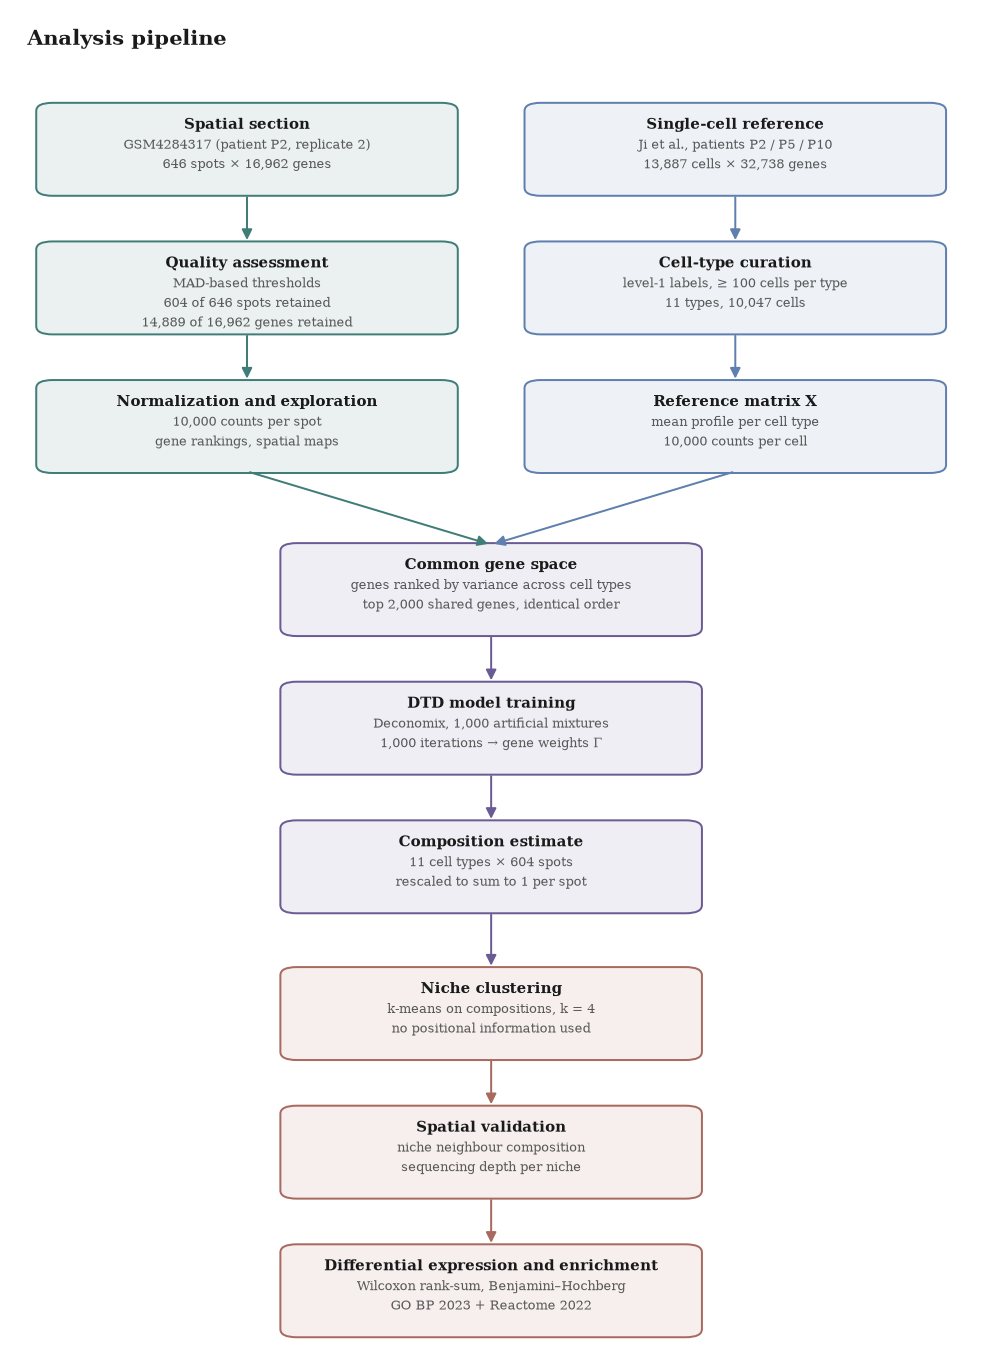

In [69]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

TEAL, BLUE, PURPLE, RED = "#3f7d78", "#5f7fae", "#6b5b95", "#a8695f"
BOX_W, BOX_H = 2.55, 1.10

# (x, y, colour, title, detail lines)
NODES = [
    (-1.50, 15.0, TEAL,   "Spatial section",
     ["GSM4284317 (patient P2, replicate 2)", "646 spots × 16,962 genes"]),
    ( 1.50, 15.0, BLUE,   "Single-cell reference",
     ["Ji et al., patients P2 / P5 / P10", "13,887 cells × 32,738 genes"]),

    (-1.50, 13.3, TEAL,   "Quality assessment",
     ["MAD-based thresholds", "604 of 646 spots retained", "14,889 of 16,962 genes retained"]),
    ( 1.50, 13.3, BLUE,   "Cell-type curation",
     ["level-1 labels, ≥ 100 cells per type", "11 types, 10,047 cells"]),

    (-1.50, 11.6, TEAL,   "Normalization and exploration",
     ["10,000 counts per spot", "gene rankings, spatial maps"]),
    ( 1.50, 11.6, BLUE,   "Reference matrix X",
     ["mean profile per cell type", "10,000 counts per cell"]),

    ( 0.00,  9.6, PURPLE, "Common gene space",
     ["genes ranked by variance across cell types", "top 2,000 shared genes, identical order"]),
    ( 0.00,  7.9, PURPLE, "DTD model training",
     ["Deconomix, 1,000 artificial mixtures", "1,000 iterations → gene weights Γ"]),
    ( 0.00,  6.2, PURPLE, "Composition estimate",
     ["11 cell types × 604 spots", "rescaled to sum to 1 per spot"]),

    ( 0.00,  4.4, RED,    "Niche clustering",
     ["k-means on compositions, k = 4", "no positional information used"]),
    ( 0.00,  2.7, RED,    "Spatial validation",
     ["niche neighbour composition", "sequencing depth per niche"]),
    ( 0.00,  1.0, RED,    "Differential expression and enrichment",
     ["Wilcoxon rank-sum, Benjamini–Hochberg", "GO BP 2023 + Reactome 2022"]),
]

# (from index, to index)
EDGES = [(0, 2), (1, 3), (2, 4), (3, 5),
         (4, 6), (5, 6),
         (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)]

fig, ax = plt.subplots(figsize=(9, 12.5))

for x, y, color, title, lines in NODES:
    ax.add_patch(FancyBboxPatch((x - BOX_W / 2, y - BOX_H / 2), BOX_W, BOX_H,
                                boxstyle="round,pad=0.02,rounding_size=0.10",
                                linewidth=1.3, edgecolor=color, facecolor=color + "1A"))
    ax.text(x, y + 0.30, title, ha="center", va="center",
            fontsize=10, fontweight="bold", color="#1a1a1a")
    for i, line in enumerate(lines):
        ax.text(x, y + 0.05 - 0.24 * i, line, ha="center", va="center",
                fontsize=8.2, color="0.35")

for i, j in EDGES:
    x0, y0, color0, *_ = NODES[i]
    x1, y1, *_ = NODES[j]
    ax.add_patch(FancyArrowPatch((x0, y0 - BOX_H / 2), (x1, y1 + BOX_H / 2),
                                 arrowstyle="-|>", mutation_scale=14,
                                 linewidth=1.3, color=color0,
                                 shrinkA=2, shrinkB=2))

ax.text(-2.85, 16.35, "Analysis pipeline", fontsize=14, fontweight="bold",
        ha="left", va="center", color="#1a1a1a")


ax.set_xlim(-2.95, 2.95)
ax.set_ylim(0.2, 16.7)
ax.axis("off")

plt.tight_layout()
save_fig(fig, "18_pipeline")
plt.show()